## human activity recognition com sensores de smartphone

neste notebook, o objetivo é explorar o dataset de treino do projeto de reconhecimento de atividades humanas. a proposta é entender a estrutura dos dados, avaliar a qualidade da base, observar o comportamento da variável alvo `Activity` e identificar padrões que possam orientar a etapa de modelagem.

o problema envolve **human activity recognition (HAR)**, uma tarefa em que sinais capturados por sensores são usados para inferir qual atividade uma pessoa está realizando. neste caso, os dados vêm de sensores de smartphone, especialmente acelerômetro e giroscópio, e já foram transformados em um conjunto amplo de features estatísticas e no domínio da frequência.

como a variável alvo possui várias categorias possíveis, este é um problema de **classificação multiclasse**. as classes representam atividades como caminhar, subir escadas, descer escadas, sentar, ficar em pé e deitar.

## dicionário de dados

antes de explorar gráficos e estatísticas, vale organizar a leitura das variáveis. este dataset combina a coluna alvo, o identificador do participante e centenas de features derivadas dos sinais do acelerômetro e do giroscópio.

### colunas principais

- `Activity`: atividade realizada pelo participante. é a variável alvo do projeto.
- `subject`: identificador do voluntário que executou a atividade.

### classes da variável alvo

- `WALKING`: caminhada em superfície plana.
- `WALKING_UPSTAIRS`: caminhada subindo escadas.
- `WALKING_DOWNSTAIRS`: caminhada descendo escadas.
- `SITTING`: participante sentado.
- `STANDING`: participante em pé.
- `LAYING`: participante deitado.

### como interpretar os nomes das features

os nomes das colunas seguem padrões. entender esses blocos ajuda bastante na leitura do dataset:

- prefixo `t`: feature calculada no domínio do tempo.
- prefixo `f`: feature calculada no domínio da frequência.
- `BodyAcc`: aceleração do corpo.
- `GravityAcc`: componente de gravidade.
- `BodyGyro`: velocidade angular medida pelo giroscópio.
- `Jerk`: variação brusca do sinal ao longo do tempo.
- `Mag`: magnitude do vetor resultante.

### medidas estatísticas mais comuns

- `mean()`: média do sinal.
- `std()`: desvio padrão.
- `mad()`: median absolute deviation.
- `max()` e `min()`: valores máximo e mínimo.
- `sma()`: signal magnitude area.
- `energy()`: energia do sinal.
- `iqr()`: intervalo interquartil.
- `entropy()`: entropia.
- `arCoeff()`: coeficientes autorregressivos.
- `correlation()`: correlação entre eixos.
- `bandsEnergy()`: energia em bandas de frequência.
- `meanFreq()`: frequência média.
- `skewness()` e `kurtosis()`: assimetria e curtose.
- `angle(...)`: ângulos entre vetores do movimento e componentes da gravidade.

### exemplos de famílias de variáveis

- `tBodyAcc-*`: estatísticas da aceleração corporal no tempo.
- `tGravityAcc-*`: estatísticas da gravidade no tempo.
- `tBodyGyro-*`: estatísticas do giroscópio no tempo.
- `fBodyAcc-*`: estatísticas da aceleração corporal no domínio da frequência.
- `fBodyGyro-*`: estatísticas do giroscópio no domínio da frequência.
- `angle(...)`: medidas angulares que ajudam a distinguir postura e orientação corporal.

esse glossário não substitui a documentação oficial do dataset, mas serve como guia prático para interpretar melhor os resultados da análise exploratória

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from IPython.display import display, Markdown
except ImportError:
    def display(obj):
        print(obj)
    def Markdown(text):
        return text
from matplotlib.colors import LinearSegmentedColormap
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

dark_palette = [
    "#4B000F",
    "#7A001F",
    "#A83246",
    "#C45A6A",
    "#1F1F2E",
    "#8D99AE",
    "#D8DEE9"
]

sns.set_theme(
    style="whitegrid",
    palette=dark_palette,
    font_scale=1.05
)

plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12
plt.rcParams["xtick.labelsize"] = 10
plt.rcParams["ytick.labelsize"] = 10
plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

cmap = LinearSegmentedColormap.from_list("sensor_dark", dark_palette)
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

## carregamento dos dados
o conjunto `train.csv` será usado como base para toda a análise exploratória

In [2]:
df = pd.read_csv("../data/train.csv")
df.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-min()-Z,tBodyAcc-sma(),tBodyAcc-energy()-X,tBodyAcc-energy()-Y,tBodyAcc-energy()-Z,tBodyAcc-iqr()-X,tBodyAcc-iqr()-Y,tBodyAcc-iqr()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,"tBodyAcc-arCoeff()-X,1","tBodyAcc-arCoeff()-X,2","tBodyAcc-arCoeff()-X,3","tBodyAcc-arCoeff()-X,4","tBodyAcc-arCoeff()-Y,1","tBodyAcc-arCoeff()-Y,2","tBodyAcc-arCoeff()-Y,3","tBodyAcc-arCoeff()-Y,4","tBodyAcc-arCoeff()-Z,1","tBodyAcc-arCoeff()-Z,2","tBodyAcc-arCoeff()-Z,3","tBodyAcc-arCoeff()-Z,4","tBodyAcc-correlation()-X,Y","tBodyAcc-correlation()-X,Z","tBodyAcc-correlation()-Y,Z",tGravityAcc-mean()-X,tGravityAcc-mean()-Y,tGravityAcc-mean()-Z,tGravityAcc-std()-X,tGravityAcc-std()-Y,tGravityAcc-std()-Z,tGravityAcc-mad()-X,tGravityAcc-mad()-Y,tGravityAcc-mad()-Z,tGravityAcc-max()-X,tGravityAcc-max()-Y,tGravityAcc-max()-Z,tGravityAcc-min()-X,tGravityAcc-min()-Y,tGravityAcc-min()-Z,tGravityAcc-sma(),tGravityAcc-energy()-X,tGravityAcc-energy()-Y,tGravityAcc-energy()-Z,tGravityAcc-iqr()-X,...,fBodyAccMag-std(),fBodyAccMag-mad(),fBodyAccMag-max(),fBodyAccMag-min(),fBodyAccMag-sma(),fBodyAccMag-energy(),fBodyAccMag-iqr(),fBodyAccMag-entropy(),fBodyAccMag-maxInds,fBodyAccMag-meanFreq(),fBodyAccMag-skewness(),fBodyAccMag-kurtosis(),fBodyBodyAccJerkMag-mean(),fBodyBodyAccJerkMag-std(),fBodyBodyAccJerkMag-mad(),fBodyBodyAccJerkMag-max(),fBodyBodyAccJerkMag-min(),fBodyBodyAccJerkMag-sma(),fBodyBodyAccJerkMag-energy(),fBodyBodyAccJerkMag-iqr(),fBodyBodyAccJerkMag-entropy(),fBodyBodyAccJerkMag-maxInds,fBodyBodyAccJerkMag-meanFreq(),fBodyBodyAccJerkMag-skewness(),fBodyBodyAccJerkMag-kurtosis(),fBodyBodyGyroMag-mean(),fBodyBodyGyroMag-std(),fBodyBodyGyroMag-mad(),fBodyBodyGyroMag-max(),fBodyBodyGyroMag-min(),fBodyBodyGyroMag-sma(),fBodyBodyGyroMag-energy(),fBodyBodyGyroMag-iqr(),fBodyBodyGyroMag-entropy(),fBodyBodyGyroMag-maxInds,fBodyBodyGyroMag-meanFreq(),fBodyBodyGyroMag-skewness(),fBodyBodyGyroMag-kurtosis(),fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-std(),fBodyBodyGyroJerkMag-mad(),fBodyBodyGyroJerkMag-max(),fBodyBodyGyroJerkMag-min(),fBodyBodyGyroJerkMag-sma(),fBodyBodyGyroJerkMag-energy(),fBodyBodyGyroJerkMag-iqr(),fBodyBodyGyroJerkMag-entropy(),fBodyBodyGyroJerkMag-maxInds,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,-0.567378,-0.744413,0.852947,0.685845,0.814263,-0.965523,-0.999945,-0.999863,-0.994612,-0.994231,-0.987614,-0.943220,-0.407747,-0.679338,-0.602122,0.929294,-0.853011,0.359910,-0.058526,0.256892,-0.224848,0.264106,-0.095246,0.278851,-0.465085,0.491936,-0.190884,0.376314,0.435129,0.660790,0.963396,-0.140840,0.115375,-0.985250,-0.981708,-0.877625,-0.985001,-0.984416,-0.894677,0.892055,-0.161265,0.124660,0.977436,-0.123213,0.056483,-0.375426,0.899469,-0.970905,-0.975510,-0.984325,...,-0.956134,-0.948870,-0.974321,-0.925722,-0.952155,-0.998285,-0.973273,-0.646376,-0.793103,-0.088436,-0.436471,-0.796840,-0.993726,-0.993755,-0.991976,-0.993365,-0.988175,-0.993726,-0.999918,-0.991364,-1.0,-0.936508,0.346989,-0.516080,-0.802760,-0.980135,-0.961309,-0.973653,-0.952264,-0.989498,-0.980135,-0.999240,-0.992656,-0.701291,-1.000000,-0.128989,0.586156,0.374605,-0.991990,-0.990697,-0.989941,-0.992448,-0.991048,-0.991990,-0.999937,-0.990458,-0.871306,-1.000000,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-

## visão geral do dataset

antes de examinar relações mais específicas, vale entender a estrutura geral da base: dimensões, tipos de dados, estatísticas descritivas, presença de valores ausentes e possíveis duplicatas

In [3]:
display(df.head())
print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas")

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,tBodyAcc-max()-Y,tBodyAcc-max()-Z,tBodyAcc-min()-X,tBodyAcc-min()-Y,tBodyAcc-min()-Z,tBodyAcc-sma(),tBodyAcc-energy()-X,tBodyAcc-energy()-Y,tBodyAcc-energy()-Z,tBodyAcc-iqr()-X,tBodyAcc-iqr()-Y,tBodyAcc-iqr()-Z,tBodyAcc-entropy()-X,tBodyAcc-entropy()-Y,tBodyAcc-entropy()-Z,"tBodyAcc-arCoeff()-X,1","tBodyAcc-arCoeff()-X,2","tBodyAcc-arCoeff()-X,3","tBodyAcc-arCoeff()-X,4","tBodyAcc-arCoeff()-Y,1","tBodyAcc-arCoeff()-Y,2","tBodyAcc-arCoeff()-Y,3","tBodyAcc-arCoeff()-Y,4","tBodyAcc-arCoeff()-Z,1","tBodyAcc-arCoeff()-Z,2","tBodyAcc-arCoeff()-Z,3","tBodyAcc-arCoeff()-Z,4","tBodyAcc-correlation()-X,Y","tBodyAcc-correlation()-X,Z","tBodyAcc-correlation()-Y,Z",tGravityAcc-mean()-X,tGravityAcc-mean()-Y,tGravityAcc-mean()-Z,tGravityAcc-std()-X,tGravityAcc-std()-Y,tGravityAcc-std()-Z,tGravityAcc-mad()-X,tGravityAcc-mad()-Y,tGravityAcc-mad()-Z,tGravityAcc-max()-X,tGravityAcc-max()-Y,tGravityAcc-max()-Z,tGravityAcc-min()-X,tGravityAcc-min()-Y,tGravityAcc-min()-Z,tGravityAcc-sma(),tGravityAcc-energy()-X,tGravityAcc-energy()-Y,tGravityAcc-energy()-Z,tGravityAcc-iqr()-X,...,fBodyAccMag-std(),fBodyAccMag-mad(),fBodyAccMag-max(),fBodyAccMag-min(),fBodyAccMag-sma(),fBodyAccMag-energy(),fBodyAccMag-iqr(),fBodyAccMag-entropy(),fBodyAccMag-maxInds,fBodyAccMag-meanFreq(),fBodyAccMag-skewness(),fBodyAccMag-kurtosis(),fBodyBodyAccJerkMag-mean(),fBodyBodyAccJerkMag-std(),fBodyBodyAccJerkMag-mad(),fBodyBodyAccJerkMag-max(),fBodyBodyAccJerkMag-min(),fBodyBodyAccJerkMag-sma(),fBodyBodyAccJerkMag-energy(),fBodyBodyAccJerkMag-iqr(),fBodyBodyAccJerkMag-entropy(),fBodyBodyAccJerkMag-maxInds,fBodyBodyAccJerkMag-meanFreq(),fBodyBodyAccJerkMag-skewness(),fBodyBodyAccJerkMag-kurtosis(),fBodyBodyGyroMag-mean(),fBodyBodyGyroMag-std(),fBodyBodyGyroMag-mad(),fBodyBodyGyroMag-max(),fBodyBodyGyroMag-min(),fBodyBodyGyroMag-sma(),fBodyBodyGyroMag-energy(),fBodyBodyGyroMag-iqr(),fBodyBodyGyroMag-entropy(),fBodyBodyGyroMag-maxInds,fBodyBodyGyroMag-meanFreq(),fBodyBodyGyroMag-skewness(),fBodyBodyGyroMag-kurtosis(),fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-std(),fBodyBodyGyroJerkMag-mad(),fBodyBodyGyroJerkMag-max(),fBodyBodyGyroJerkMag-min(),fBodyBodyGyroJerkMag-sma(),fBodyBodyGyroJerkMag-energy(),fBodyBodyGyroJerkMag-iqr(),fBodyBodyGyroJerkMag-entropy(),fBodyBodyGyroJerkMag-maxInds,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",subject,Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,-0.567378,-0.744413,0.852947,0.685845,0.814263,-0.965523,-0.999945,-0.999863,-0.994612,-0.994231,-0.987614,-0.943220,-0.407747,-0.679338,-0.602122,0.929294,-0.853011,0.359910,-0.058526,0.256892,-0.224848,0.264106,-0.095246,0.278851,-0.465085,0.491936,-0.190884,0.376314,0.435129,0.660790,0.963396,-0.140840,0.115375,-0.985250,-0.981708,-0.877625,-0.985001,-0.984416,-0.894677,0.892055,-0.161265,0.124660,0.977436,-0.123213,0.056483,-0.375426,0.899469,-0.970905,-0.975510,-0.984325,...,-0.956134,-0.948870,-0.974321,-0.925722,-0.952155,-0.998285,-0.973273,-0.646376,-0.793103,-0.088436,-0.436471,-0.796840,-0.993726,-0.993755,-0.991976,-0.993365,-0.988175,-0.993726,-0.999918,-0.991364,-1.0,-0.936508,0.346989,-0.516080,-0.802760,-0.980135,-0.961309,-0.973653,-0.952264,-0.989498,-0.980135,-0.999240,-0.992656,-0.701291,-1.000000,-0.128989,0.586156,0.374605,-0.991990,-0.990697,-0.989941,-0.992448,-0.991048,-0.991990,-0.999937,-0.990458,-0.871306,-1.000000,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,1,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-

Dimensões do dataset: 7352 linhas e 563 colunas


In [4]:
df.shape

(7352, 563)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7352 entries, 0 to 7351
Columns: 563 entries, tBodyAcc-mean()-X to Activity
dtypes: float64(561), int64(1), object(1)
memory usage: 31.6+ MB


In [6]:
display(df.describe(include="all").T.head(15))
display(df.describe().T.head(15))
display(df.describe().T.head(15))
display(df.describe(include="object").T)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
tBodyAcc-mean()-X,7352.0,NaN,NaN,NaN,0.274488,0.070261,-1.0,0.262975,0.277193,0.288461,1.0
tBodyAcc-mean()-Y,7352.0,NaN,NaN,NaN,-0.017695,0.040811,-1.0,-0.024863,-0.017219,-0.010783,1.0
tBodyAcc-mean()-Z,7352.0,NaN,NaN,NaN,-0.109141,0.056635,-1.0,-0.120993,-0.108676,-0.097794,1.0
tBodyAcc-std()-X,7352.0,NaN,NaN,NaN,-0.605438,0.448734,-1.0,-0.992754,-0.946196,-0.242813,1.0
tBodyAcc-std()-Y,7352.0,NaN,NaN,NaN,-0.510938,0.502645,-0.999873,-0.978129,-0.851897,-0.034231,0.916238
tBodyAcc-std()-Z,7352.0,NaN,NaN,NaN,-0.604754,0.418687,-1.0,-0.980233,-0.859365,-0.262415,1.0
tBodyAcc-mad()-X,7352.0,NaN,NaN,NaN,-0.630512,0.424073,-1.0,-0.993591,-0.950709,-0.29268,1.0
tBodyAcc-mad()-Y,7352.0,NaN,NaN,NaN,-0.526907,0.485942,-1.0,-0.978162,-0.857328,-0.066701,0.967664
tBodyAcc-mad()-Z,7352.0,NaN,NaN,NaN,-0.60615,0.414122,-1.0,-0.980251,-0.857143,-0.265671,1.0
tBodyAcc-max()-X,7352.0,NaN,NaN,NaN,-0.468604,0.544547,-1.0,-0.936219,-0.881637,-0.017129,1.0


,count,mean,std,min,25%,50%,75%,max
tBodyAcc-mean()-X,7352.0,0.274488,0.070261,-1.000000,0.262975,0.277193,0.288461,1.000000
tBodyAcc-mean()-Y,7352.0,-0.017695,0.040811,-1.000000,-0.024863,-0.017219,-0.010783,1.000000
tBodyAcc-mean()-Z,7352.0,-0.109141,0.056635,-1.000000,-0.120993,-0.108676,-0.097794,1.000000
tBodyAcc-std()-X,7352.0,-0.605438,0.448734,-1.000000,-0.992754,-0.946196,-0.242813,1.000000
tBodyAcc-std()-Y,7352.0,-0.510938,0.502645,-0.999873,-0.978129,-0.851897,-0.034231,0.916238
tBodyAcc-std()-Z,7352.0,-0.604754,0.418687,-1.000000,-0.980233,-0.859365,-0.262415,1.000000
tBodyAcc-mad()-X,7352.0,-0.630512,0.424073,-1.000000,-0.993591,-0.950709,-0.292680,1.000000
tBodyAcc-mad()-Y,7352.0,-0.526907,0.485942,-1.000000,-0.978162,-0.857328,-0.066701,0.967664
tBodyAcc-mad()-Z,7352.0,-0.606150,0.414122,-1.000000,-0.980251,-0.857143,-0.265671,1.000000
tBodyAcc-max()-X,7352.0,-0.468604,0.544547,-1.000000,-0.936219,-0.881637,-0.017129,1.000000


,count,mean,std,min,25%,50%,75%,max
tBodyAcc-mean()-X,7352.0,0.274488,0.070261,-1.000000,0.262975,0.277193,0.288461,1.000000
tBodyAcc-mean()-Y,7352.0,-0.017695,0.040811,-1.000000,-0.024863,-0.017219,-0.010783,1.000000
tBodyAcc-mean()-Z,7352.0,-0.109141,0.056635,-1.000000,-0.120993,-0.108676,-0.097794,1.000000
tBodyAcc-std()-X,7352.0,-0.605438,0.448734,-1.000000,-0.992754,-0.946196,-0.242813,1.000000
tBodyAcc-std()-Y,7352.0,-0.510938,0.502645,-0.999873,-0.978129,-0.851897,-0.034231,0.916238
tBodyAcc-std()-Z,7352.0,-0.604754,0.418687,-1.000000,-0.980233,-0.859365,-0.262415,1.000000
tBodyAcc-mad()-X,7352.0,-0.630512,0.424073,-1.000000,-0.993591,-0.950709,-0.292680,1.000000
tBodyAcc-mad()-Y,7352.0,-0.526907,0.485942,-1.000000,-0.978162,-0.857328,-0.066701,0.967664
tBodyAcc-mad()-Z,7352.0,-0.606150,0.414122,-1.000000,-0.980251,-0.857143,-0.265671,1.000000
tBodyAcc-max()-X,7352.0,-0.468604,0.544547,-1.000000,-0.936219,-0.881637,-0.017129,1.000000


,count,unique,top,freq
Activity,7352,6,LAYING,1407


### qualidade dos dados

`describe()` ajuda a resumir o comportamento das variáveis. como o dataset possui centenas de features numéricas derivadas dos sensores, faz sentido visualizar apenas uma parte da tabela no notebook e deixar o restante acessível para inspeção quando necessário

In [7]:
missing_values = df.isna().sum().sort_values(ascending=False)
null_summary = missing_values[missing_values > 0]

duplicates = df.duplicated().sum()
unique_counts = df.nunique().sort_values()
dtype_summary = df.dtypes.astype(str).value_counts().rename_axis("dtype").reset_index(name="count")

summary_overview = pd.DataFrame({
    "métrica": [
        "linhas",
        "colunas",
        "valores nulos totais",
        "linhas duplicadas",
        "colunas numéricas",
        "colunas categóricas"
    ],
    "valor": [
        df.shape[0],
        df.shape[1],
        int(df.isna().sum().sum()),
        int(duplicates),
        int(df.select_dtypes(include="number").shape[1]),
        int(df.select_dtypes(exclude="number").shape[1])
    ]
})

display(summary_overview)
display(dtype_summary)
display(unique_counts.head(15).rename("valores_únicos").to_frame())
display(unique_counts.tail(15).rename("valores_únicos").to_frame())

if null_summary.empty:
    print("Nenhuma coluna possui valores nulos.")
else:
    display(null_summary.rename("valores_nulos").to_frame())

,métrica,valor
0,linhas,7352
1,colunas,563
2,valores nulos totais,0
3,linhas duplicadas,0
4,colunas numéricas,562
5,colunas categóricas,1


,dtype,count
0,float64,561
1,int64,1
2,object,1


,valores_únicos
Activity,6
subject,21
fBodyGyro-maxInds-Z,25
fBodyAcc-maxInds-Z,26
fBodyAcc-maxInds-Y,26
fBodyBodyGyroMag-maxInds,27
fBodyGyro-maxInds-X,27
fBodyAcc-maxInds-X,29
fBodyAccMag-maxInds,29
fBodyGyro-maxInds-Y,29


,valores_únicos
"tBodyAccJerk-arCoeff()-Y,4",7352
"tBodyAccJerk-arCoeff()-Z,1",7352
"tBodyAccJerk-arCoeff()-Z,2",7352
"tBodyGyroJerk-correlation()-Y,Z",7352
"tBodyGyroJerk-correlation()-X,Z",7352
"tBodyGyroJerk-arCoeff()-Z,4",7352
"tBodyGyroJerk-arCoeff()-Z,3",7352
"tBodyGyroJerk-arCoeff()-Z,2",7352
"tBodyGyroJerk-arCoeff()-Z,1",7352
"tBodyGyroJerk-arCoeff()-Y,4",7352


Nenhuma coluna possui valores nulos.


## análise da variável alvo

como a tarefa é multiclasse, a distribuição de `Activity` merece atenção. aqui vamos observar a contagem absoluta, a proporção percentual e um gráfico de barras para entender se as classes estão equilibradas ou se existe alguma concentração maior em determinadas atividades

,contagem,percentual
Activity,,
LAYING,1407,19.14
STANDING,1374,18.69
SITTING,1286,17.49
WALKING,1226,16.68
WALKING_UPSTAIRS,1073,14.59
WALKING_DOWNSTAIRS,986,13.41


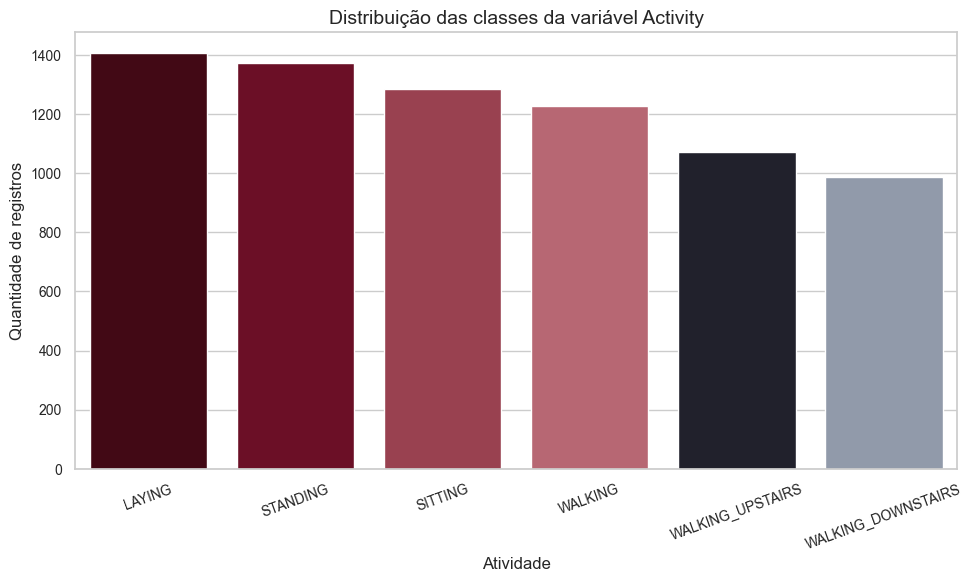

In [8]:
target_counts = df["Activity"].value_counts().sort_values(ascending=False)
target_percentages = df["Activity"].value_counts(normalize=True).mul(100).round(2)

activity_distribution = pd.DataFrame({
    "contagem": target_counts,
    "percentual": target_percentages
})

display(activity_distribution)

plt.figure(figsize=(10, 6))
sns.barplot(
    x=target_counts.index,
    y=target_counts.values,
    hue=target_counts.index,
    palette=dark_palette[:6],
    legend=False
)
plt.title("Distribuição das classes da variável Activity")
plt.xlabel("Atividade")
plt.ylabel("Quantidade de registros")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [9]:
balance_ratio = target_counts.max() / target_counts.min()
print(f"{balance_ratio:.2f}")

1.43


a razão entre a classe mais frequente e a menos frequente é de 1.43. isso indica que o dataset está relativamente bem distribuído, embora atividades como `LAYING` e `STANDING` apareçam um pouco mais do que `WALKING_DOWNSTAIRS`

essa razão serve para medir o nível de desequilíbrio entre classes

quanto mais perto de 1, mais balanceado o dataset tende a estar

## análise geral das features

as variáveis numéricas deste dataset não são leituras brutas dos sensores. em grande parte, elas já representam medidas agregadas extraídas dos sinais, como médias, desvios, energia, entropia, correlação, magnitude e componentes no domínio da frequência

por isso, esta seção foca em uma leitura geral sendo a quantidade de features, escalas, dispersão e identificação de colunas com baixa variabilidade

In [10]:
numeric_cols = df.select_dtypes(include="number").columns.tolist()
numeric_features = [col for col in numeric_cols if col != "subject"]

print(f"Quantidade de features numéricas (incluindo subject): {len(numeric_cols)}")
print(f"Quantidade de features numéricas usadas como sinal do sensor (sem subject): {len(numeric_features)}")

feature_stats = df[numeric_features].describe().T
feature_stats["variance"] = df[numeric_features].var()
feature_stats["range"] = feature_stats["max"] - feature_stats["min"]

display(feature_stats[["mean", "std", "min", "25%", "50%", "75%", "max", "variance", "range"]].head(15))

mean_abs = feature_stats["mean"].abs().sort_values(ascending=False).head(10).rename("média_absoluta")
std_top = feature_stats["std"].sort_values(ascending=False).head(10).rename("desvio_padrão")
variance_low = feature_stats["variance"].sort_values().head(10).rename("variância")

display(mean_abs.to_frame())
display(std_top.to_frame())
display(variance_low.to_frame())

Quantidade de features numéricas (incluindo subject): 562
Quantidade de features numéricas usadas como sinal do sensor (sem subject): 561


,mean,std,min,25%,50%,75%,max,variance,range
tBodyAcc-mean()-X,0.274488,0.070261,-1.000000,0.262975,0.277193,0.288461,1.000000,0.004937,2.000000
tBodyAcc-mean()-Y,-0.017695,0.040811,-1.000000,-0.024863,-0.017219,-0.010783,1.000000,0.001665,2.000000
tBodyAcc-mean()-Z,-0.109141,0.056635,-1.000000,-0.120993,-0.108676,-0.097794,1.000000,0.003208,2.000000
tBodyAcc-std()-X,-0.605438,0.448734,-1.000000,-0.992754,-0.946196,-0.242813,1.000000,0.201363,2.000000
tBodyAcc-std()-Y,-0.510938,0.502645,-0.999873,-0.978129,-0.851897,-0.034231,0.916238,0.252652,1.916111
tBodyAcc-std()-Z,-0.604754,0.418687,-1.000000,-0.980233,-0.859365,-0.262415,1.000000,0.175299,2.000000
tBodyAcc-mad()-X,-0.630512,0.424073,-1.000000,-0.993591,-0.950709,-0.292680,1.000000,0.179838,2.000000
tBodyAcc-mad()-Y,-0.526907,0.485942,-1.000000,-0.978162,-0.857328,-0.066701,0.967664,0.236139,1.967664
tBodyAcc-mad()-Z,-0.606150,0.414122,-1.000000,-0.980251,-0.857143,-0.265671,1.000000,0.171497,2.000000
tBodyAcc-max()-X,-0.468604,0.544547,-1.000000,-0.936219,-0.881637,-0.017129,1.000000,0.296531,2.000000


,média_absoluta
"fBodyAccJerk-bandsEnergy()-57,64",0.984059
"fBodyGyro-bandsEnergy()-33,40.1",0.976601
"fBodyGyro-bandsEnergy()-57,64",0.975576
"fBodyGyro-bandsEnergy()-57,64.1",0.974797
"fBodyGyro-bandsEnergy()-33,48.1",0.972119
"fBodyGyro-bandsEnergy()-33,40.2",0.971625
"fBodyAccJerk-bandsEnergy()-57,64.1",0.970968
"fBodyAccJerk-bandsEnergy()-57,64.2",0.969494
"fBodyGyro-bandsEnergy()-49,64",0.968865
"fBodyGyro-bandsEnergy()-57,64.2",0.968726


,desvio_padrão
fBodyAccJerk-entropy()-X,0.751733
fBodyAccJerk-entropy()-Y,0.736548
tBodyAccJerkMag-entropy(),0.727265
fBodyAcc-entropy()-X,0.725064
"tGravityAcc-correlation()-X,Z",0.707724
"tGravityAcc-correlation()-Y,Z",0.704162
tBodyGyroJerkMag-entropy(),0.703676
tGravityAcc-energy()-X,0.697904
"tGravityAcc-correlation()-X,Y",0.696636
fBodyAccMag-entropy(),0.682710


,variância
tBodyAcc-mean()-Y,0.001665
tBodyAcc-mean()-Z,0.003208
"fBodyAccJerk-bandsEnergy()-57,64",0.003367
"fBodyGyro-bandsEnergy()-33,40.1",0.004192
"fBodyGyro-bandsEnergy()-33,40.2",0.004287
"fBodyGyro-bandsEnergy()-33,48.2",0.004666
tBodyAcc-mean()-X,0.004937
"fBodyGyro-bandsEnergy()-33,48.1",0.005119
"fBodyGyro-bandsEnergy()-25,48.2",0.005165
tGravityAcc-iqr()-X,0.005378


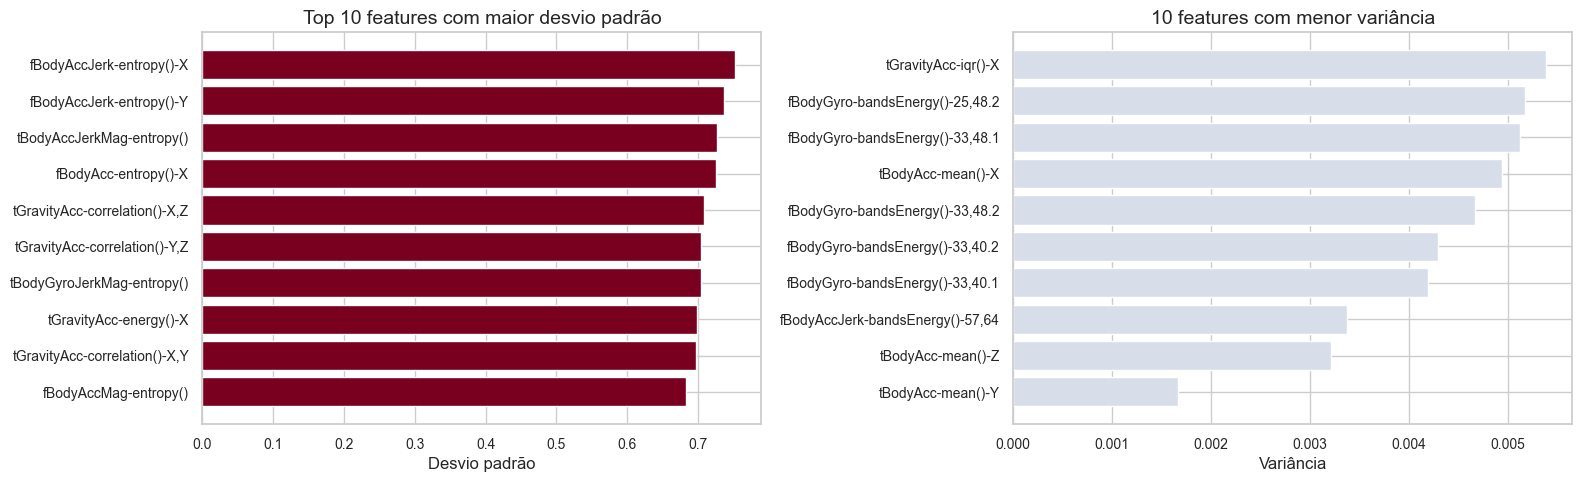

quantidade de features com variância abaixo de 0.01: 37


In [11]:
low_variance_features = feature_stats[feature_stats["variance"] < 0.01].sort_values("variance")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_std = feature_stats["std"].sort_values(ascending=False).head(10).sort_values()
axes[0].barh(top_std.index, top_std.values, color=dark_palette[1])
axes[0].set_title("Top 10 features com maior desvio padrão")
axes[0].set_xlabel("Desvio padrão")

low_var_plot = feature_stats["variance"].sort_values().head(10)
axes[1].barh(low_var_plot.index, low_var_plot.values, color=dark_palette[6])
axes[1].set_title("10 features com menor variância")
axes[1].set_xlabel("Variância")

plt.tight_layout()
plt.show()

print(f"quantidade de features com variância abaixo de 0.01: {low_variance_features.shape[0]}")

- features com alta variabilidade mudam bastante entre as observações. isso pode indicar que elas capturam diferenças relevantes entre atividades

- features com baixa variabilidade mudam pouco ao longo da base. em geral, elas tendem a carregar menos informação discriminativa sozinhas

- o dataset tem um grupo de variáveis que quase não varia, então elas podem ter baixo poder de separação
- ao mesmo tempo, há features com dispersão bem maior, especialmente ligadas a entropy, energy e algumas medidas de correlação/gravity, o que sugere que essas famílias podem ser mais úteis para diferenciar atividades

- a análise de variância mostra que parte das features apresenta pouca dispersão global, o que sugere menor potencial discriminativo isolado. por outro lado, variáveis ligadas a entropia, energia e correlação exibem maior variabilidade, indicando que podem capturar diferenças mais fortes entre padrões de movimento. ainda assim, baixa variância não implica descarte automático, já que algumas features podem ser úteis em combinação com outras

## verificação de valores nulos, duplicatas e inconsistências

além das estatísticas gerais, vale verificar se há sinais de baixa qualidade na base, como colunas constantes, quase constantes, registros repetidos ou inconsistências simples

In [12]:
constant_columns = [col for col in numeric_cols if df[col].nunique() == 1]
quasi_constant_columns = [col for col in numeric_cols if df[col].nunique() <= 5]

quality_checks = pd.DataFrame({
    "checagem": [
        "valores nulos totais",
        "duplicatas",
        "colunas constantes",
        "colunas com até 5 valores únicos"
    ],
    "resultado": [
        int(df.isna().sum().sum()),
        int(df.duplicated().sum()),
        len(constant_columns),
        len(quasi_constant_columns)
    ]
})

display(quality_checks)

if constant_columns:
    display(pd.Series(constant_columns, name="colunas_constantes"))

if quasi_constant_columns:
    display(pd.Series(quasi_constant_columns, name="colunas_quase_constantes"))

,checagem,resultado
0,valores nulos totais,0
1,duplicatas,0
2,colunas constantes,0
3,colunas com até 5 valores únicos,0


## análise comparativa entre atividades

como existem centenas de colunas, não faz sentido visualizar todas individualmente. aqui vamos selecionar algumas features representativas ligadas a diferentes famílias de sensores, como `tBodyAcc`, `tGravityAcc`, `tBodyGyro`, `fBodyAcc`, `fBodyGyro` e `angle`

o objetivo é observar se essas medidas ajudam a diferenciar atividades como caminhar, sentar, ficar em pé e deitar

In [13]:
representative_features = [
    "tBodyAcc-mean()-X",
    "tBodyAcc-std()-X",
    "tGravityAcc-mean()-Y",
    "tBodyGyro-mean()-X",
    "fBodyAcc-mean()-X",
    "fBodyGyro-mean()-X",
    "angle(X,gravityMean)",
    "angle(Y,gravityMean)"
]

feature_labels = {
    "tBodyAcc-mean()-X": "Média da aceleração corporal no eixo X",
    "tBodyAcc-std()-X": "Desvio padrão da aceleração corporal no eixo X",
    "tGravityAcc-mean()-Y": "Média da aceleração da gravidade no eixo Y",
    "tBodyGyro-mean()-X": "Média da rotação corporal no eixo X",
    "fBodyAcc-mean()-X": "Média da aceleração corporal no domínio da frequência (eixo X)",
    "fBodyGyro-mean()-X": "Média da rotação corporal no domínio da frequência (eixo X)",
    "angle(X,gravityMean)": "Ângulo entre o eixo X e a gravidade média",
    "angle(Y,gravityMean)": "Ângulo entre o eixo Y e a gravidade média"
}

representative_features = [feature for feature in representative_features if feature in df.columns]
representative_features

['tBodyAcc-mean()-X',
 'tBodyAcc-std()-X',
 'tGravityAcc-mean()-Y',
 'tBodyGyro-mean()-X',
 'fBodyAcc-mean()-X',
 'fBodyGyro-mean()-X',
 'angle(X,gravityMean)',
 'angle(Y,gravityMean)']

essas features foram selecionadas como exemplos representativos de diferentes famílias de variáveis do dataset. como a base possui centenas de atributos derivados dos sensores, a ideia aqui não é afirmar que apenas essas colunas são importantes, mas sim usar um subconjunto interpretável para visualizar padrões entre as atividades

* `tBodyAcc-*`: aceleração do corpo no tempo
* `tGravityAcc-*`: componente de gravidade e postura
* `tBodyGyro-*`: rotação capturada pelo giroscópio
* `fBodyAcc-*`: aceleração no domínio da frequência
* `fBodyGyro-*`: giroscópio no domínio da frequência
* `angle(...)`: orientação do corpo em relação à gravidade

seleção feita para mostrar exemplos de movimento linear, orientação/postura, movimento angular, sinais no tempo, sinais na frequência

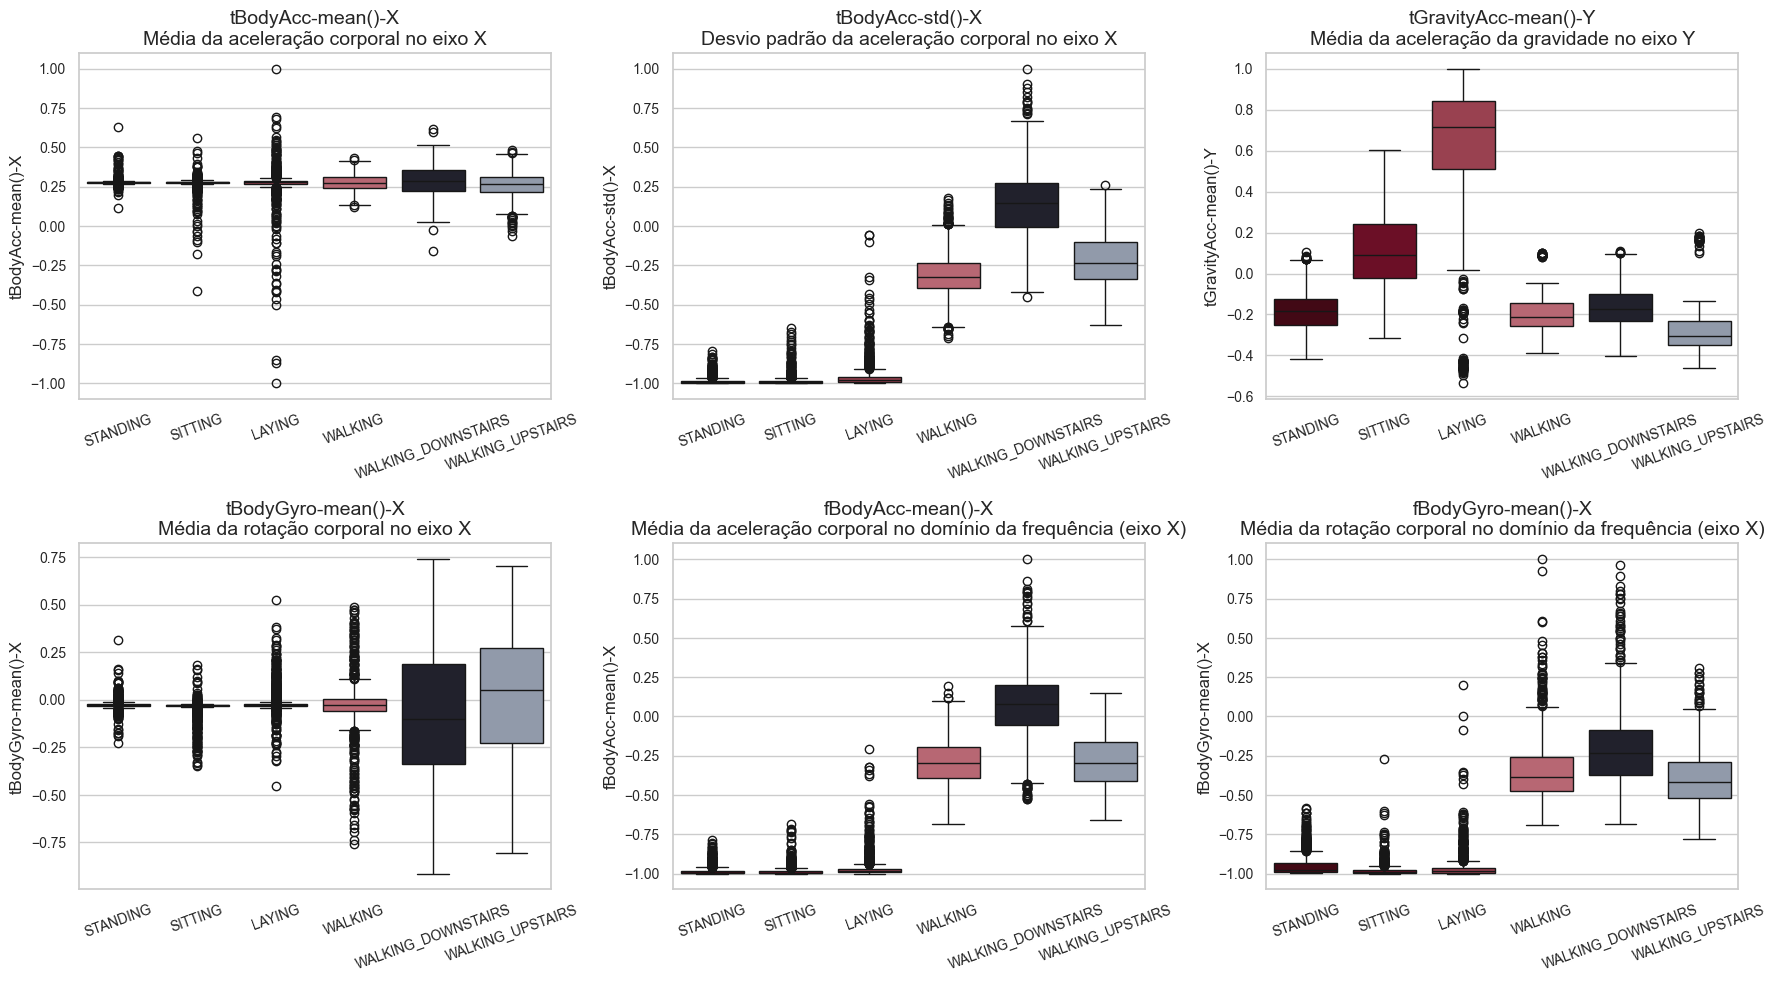

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, feature in zip(axes, representative_features[:6]):
    sns.boxplot(
        data=df,
        x="Activity",
        y=feature,
        hue="Activity",
        palette=dark_palette[:6],
        legend=False,
        ax=ax
    )
    ax.set_title(f"{feature}\n{feature_labels.get(feature, feature)}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

for ax in axes[len(representative_features[:6]):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

- os boxplots mostram que várias features conseguem diferenciar bem atividades estáticas e dinâmicas
- variáveis ligadas à aceleração, frequência e giroscópio parecem especialmente úteis para separar os padrões de movimento
- a feature `tGravityAcc-mean()-Y` destaca `LAYING` com mais clareza, sugerindo que medidas relacionadas à gravidade e à orientação corporal ajudam a identificar posturas
- por outro lado, a sobreposição entre `SITTING` e `STANDING` indica uma fronteira mais difícil, o que antecipa possíveis confusões na etapa de modelagem

    `tBodyAcc-mean()-X`
    - mostra pouca separação clara entre algumas classes
    - sozinho, não parece ser o melhor discriminador

    `tBodyAcc-std()-X`
    - separa melhor atividades estáticas e dinâmicas
    - bom sinal de que a variabilidade do movimento ajuda na classificação

    `tGravityAcc-mean()-Y`
    - muito útil para distinguir LAYING
    - forte relação com orientação corporal

    `tBodyGyro-mean()-X`
    - diferencia melhor atividades com rotação/movimento
    - ajuda mais nas atividades dinâmicas

    `fBodyAcc-mean()-X` e `fBodyGyro-mean()-X`
    - mostram que o domínio da frequência também carrega sinal útil
    - reforçam que a periodicidade e intensidade do movimento são relevantes

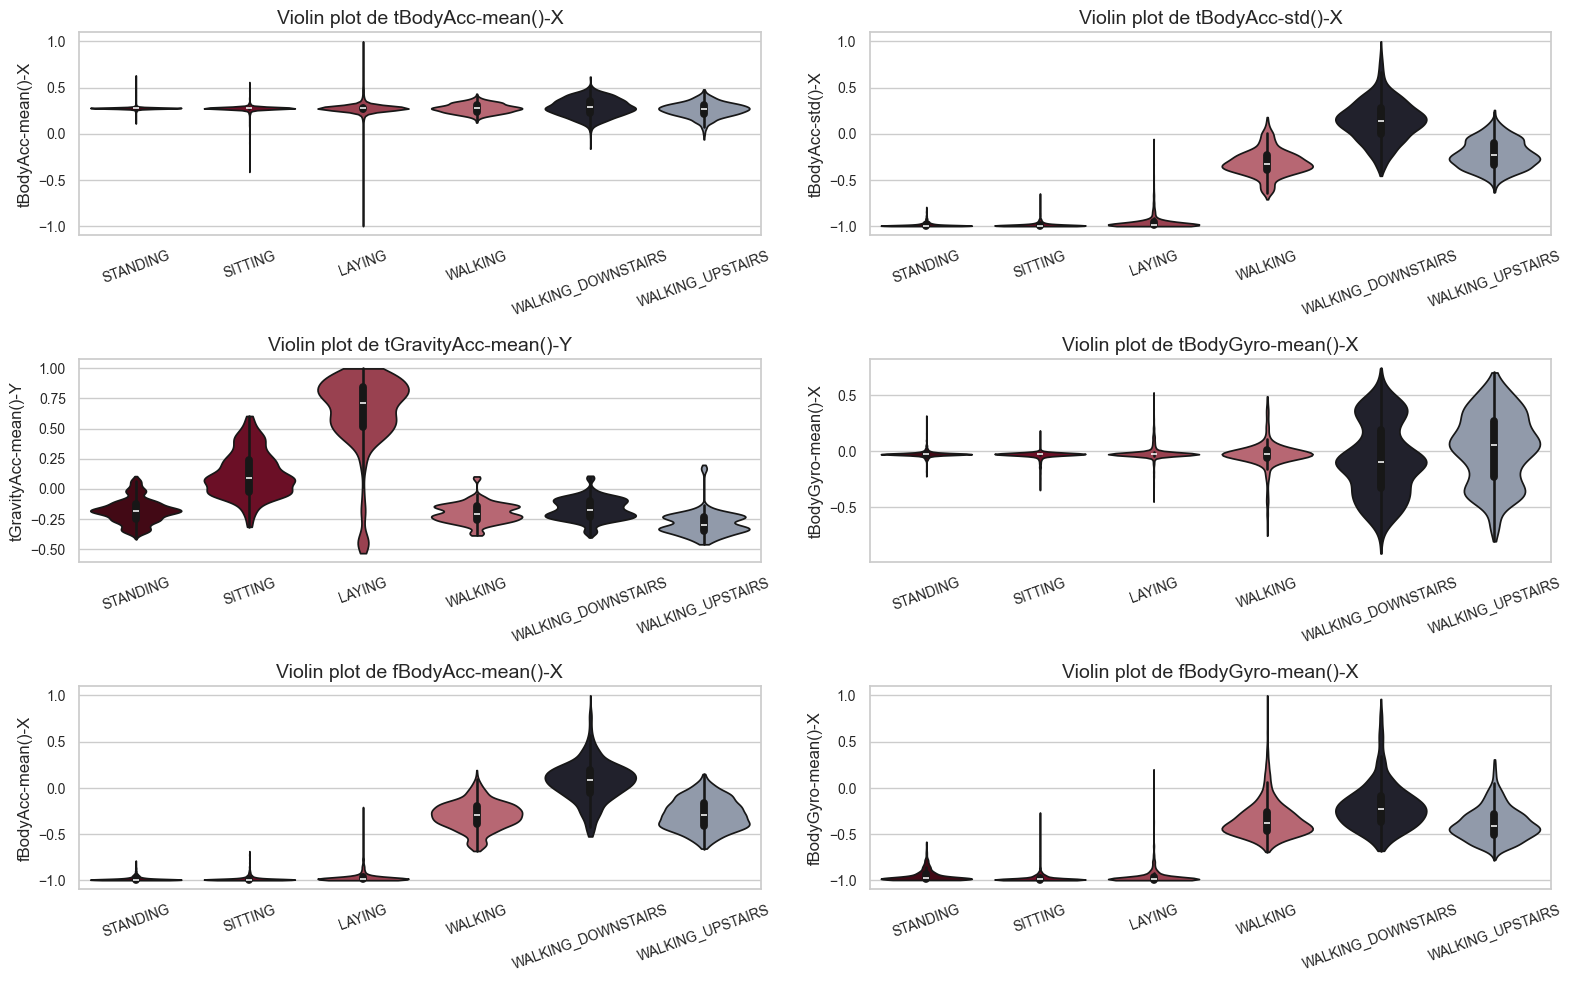

In [15]:
violin_features = representative_features[:6]

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, feature in zip(axes, violin_features):
    sns.violinplot(data=df, x="Activity", y=feature, hue="Activity", palette=dark_palette[:6], legend=False, ax=ax, cut=0)
    ax.set_title(f"Violin plot de {feature}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

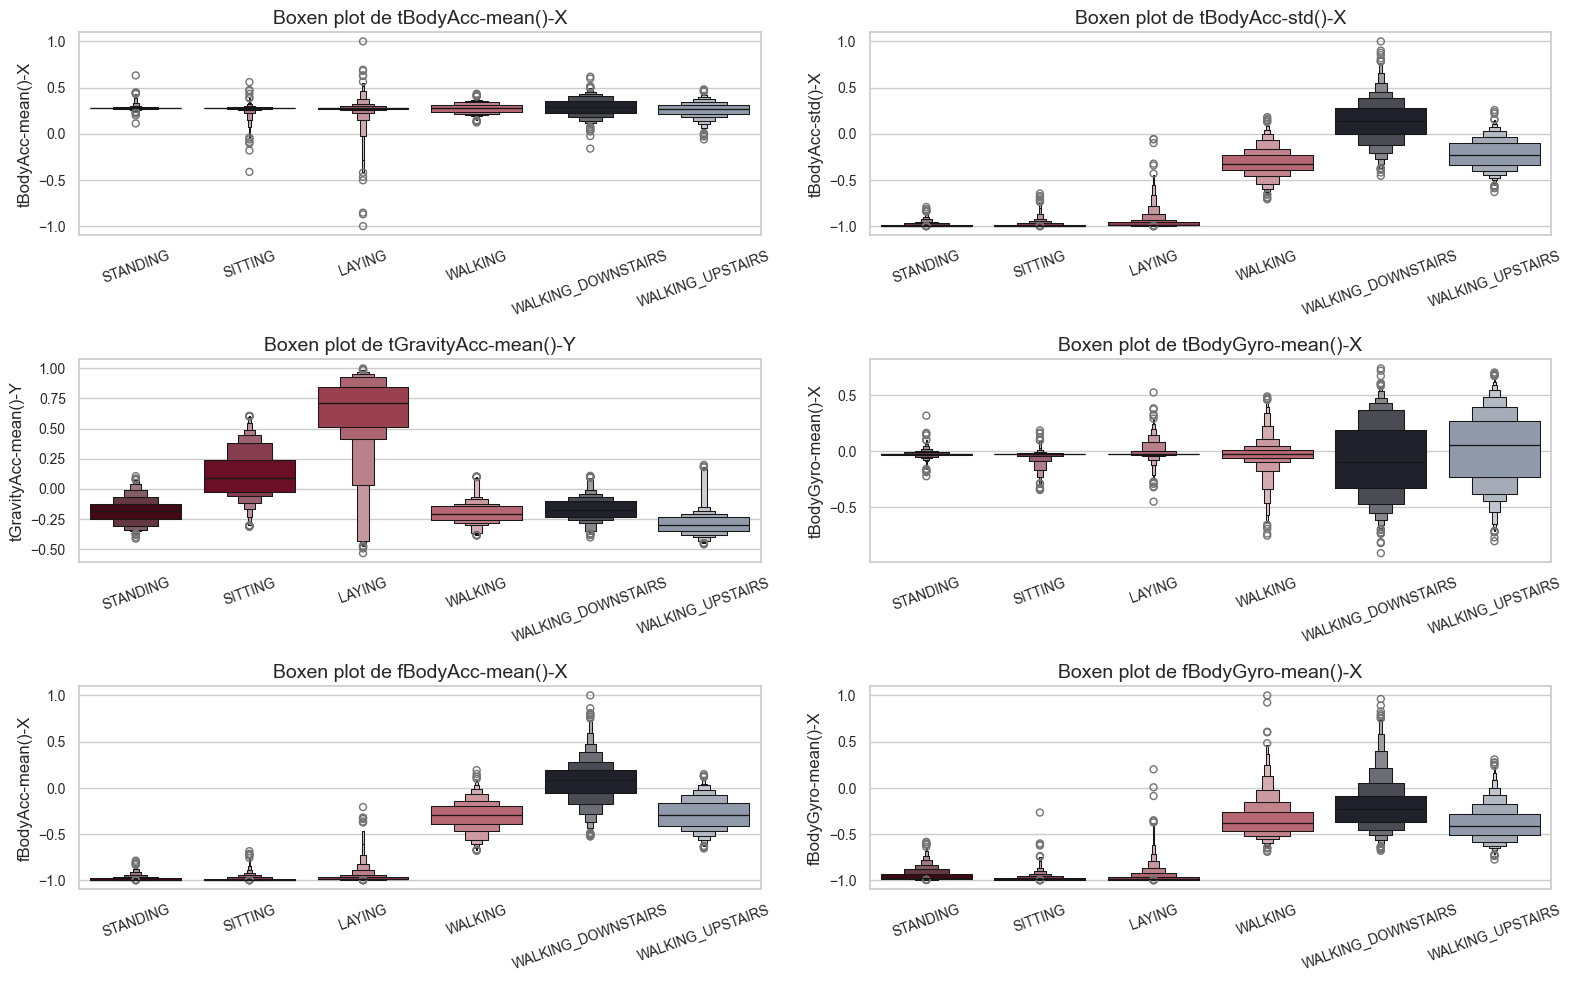

In [16]:
boxenplot_features = representative_features[:6]

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
axes = axes.flatten()

for ax, feature in zip(axes, boxenplot_features):
    sns.boxenplot(data=df, x="Activity", y=feature, hue="Activity", palette=dark_palette[:6], legend=False, ax=ax)
    ax.set_title(f"Boxen plot de {feature}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

- os boxen plots mostram que algumas features possuem maior capacidade de separação entre atividades do que outras. 
- variáveis ligadas à variabilidade do movimento e ao domínio da frequência, como `tBodyAcc-std()-X`, `fBodyAcc-mean()-X` e `fBodyGyro-mean()-X`, diferenciam com clareza atividades estáticas e dinâmicas 
- já `tGravityAcc-mean()-Y` se destaca por separar fortemente a classe `LAYING`, sugerindo que a orientação corporal em relação à gravidade é um sinal importante para reconhecer posturas
- em contrapartida, a proximidade entre `SITTING` e `STANDING` e a sobreposição parcial entre os tipos de caminhada indicam fronteiras de classificação potencialmente mais desafiadoras

    `tBodyAcc-mean()-X` - média da aceleração corporal no eixo X
    - as medianas estão relativamente próximas
    - existe alguma diferença, mas com bastante sobreposição
    - essa feature isoladamente não parece uma das mais fortes
    - ela pode contribuir em conjunto com outras, mas não separa tão bem as classes sozinha

    `tBodyAcc-std()-X` - desvio padrão da aceleração corporal no eixo X
    - `STANDING`, `SITTING` e `LAYING` ficam concentradas perto de -1
    - `WALKING`, `WALKING_DOWNSTAIRS` e `WALKING_UPSTAIRS` ficam claramente deslocadas
    - `WALKING_DOWNSTAIRS` parece ainda mais separada
    - essa é uma feature importante para distinguir atividades estáticas e dinâmicas
    - a variabilidade do movimento parece ser um sinal muito útil
    - também pode ajudar a diferenciar tipos de caminhada

    `tGravityAcc-mean()-Y` - média da aceleração da gravidade no eixo Y
    - `LAYING` está muito deslocada para cima
    - `SITTING` ocupa uma faixa intermediária
    - as outras classes ficam em valores mais baixos
    - essa feature é uma das melhores para separar LAYING
    - ela sugere que a orientação corporal em relação à gravidade é muito informativa
    - também ajuda a diferenciar posturas, não só movimento

    `tBodyGyro-mean()-X` média da rotação corporal no eixo X
    - atividades estáticas estão mais concentradas perto de zero/valores próximos
    - `WALKING_DOWNSTAIRS` e `WALKING_UPSTAIRS` têm distribuição bem mais larga
    - essa feature parece captar bem a rotação associada ao deslocamento
    - é mais útil para diferenciar atividades dinâmicas do que para separar `SITTING` e `STANDING`

    `fBodyAcc-mean()-X` - média da aceleração corporal no domínio da frequência
    - atividades estáticas estão concentradas perto de -1
    - caminhadas aparecem em faixas muito diferentes
    - `WALKING_DOWNSTAIRS` se destaca bastante
    - a informação no domínio da frequência também é muito relevante
    - isso sugere que o padrão repetitivo e a intensidade do movimento ajudam bastante a classificar atividades
    - reforça que as features derivadas dos sinais foram bem construídas

    `fBodyGyro-mean()-X` - média da rotação corporal no domínio da frequência
    - o padrão é parecido com fBodyAcc-mean()-X
    - as atividades dinâmicas ficam bem separadas das estáticas
    - ainda existe alguma sobreposição entre os tipos de caminhada
    - essa variável também parece muito útil
    - ajuda principalmente a separar movimento de não movimento
    - mas sozinha ainda não resolve totalmente a diferença entre `WALKING`, `WALKING_UPSTAIRS` e `WALKING_DOWNSTAIRS`

    `LAYING` tende a ser uma classe fácil, principalmente por causa de `tGravityAcc-mean()-Y`
    - a posição do corpo muda a relação com a gravidade, então essa classe ganha um padrão bem próprio

    `SITTING` e `STANDING` continuam sendo classes difíceis
    - em vários gráficos, elas aparecem próximas e com bastante sobreposição
    - é esperado que o modelo confunda mais essas duas atividades.

    as caminhadas são separáveis, mas não perfeitamente. as três classes de caminhada ficam diferentes das estáticas, mas ainda relativamente próximas entre si
    o modelo deve aprender bem o bloco “andar”, mas ainda pode errar entre:
    - `WALKING`
    - `WALKING_UPSTAIRS`
    - `WALKING_DOWNSTAIRS`
    
    features no domínio da frequência parecem fortes, as variáveis `fBodyAcc-*` e `fBodyGyro-*` mostram boa separação
    - não são só as estatísticas do tempo que importam; os padrões de frequência também carregam informação relevante sobre a atividade

    a dispersão muda entre atividades
    - atividades dinâmicas têm caixas mais largas e mais níveis internos no boxenplot
    - o movimento humano é mais variável durante caminhada do que em posturas estáticas, o que faz sentido

,tBodyAcc-mean()-X,tBodyAcc-std()-X,tGravityAcc-mean()-Y,tBodyGyro-mean()-X,fBodyAcc-mean()-X,fBodyGyro-mean()-X,"angle(X,gravityMean)","angle(Y,gravityMean)"
Activity,,,,,,,,
LAYING,0.269,-0.959,0.633,-0.017,-0.966,-0.960,0.517,-0.441
SITTING,0.273,-0.983,0.123,-0.038,-0.983,-0.978,-0.691,-0.004
STANDING,0.279,-0.985,-0.182,-0.026,-0.983,-0.949,-0.774,0.208
WALKING,0.276,-0.313,-0.200,-0.031,-0.299,-0.343,-0.757,0.220
WALKING_DOWNSTAIRS,0.288,0.140,-0.167,-0.077,0.071,-0.202,-0.778,0.199
WALKING_UPSTAIRS,0.262,-0.221,-0.287,0.021,-0.285,-0.388,-0.633,0.282


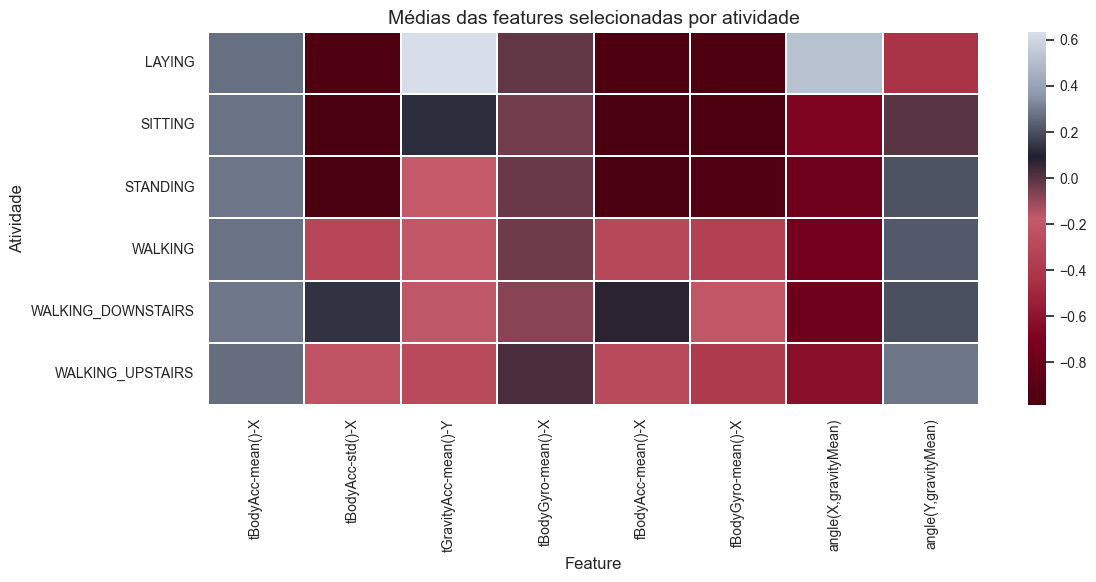

In [17]:
class_feature_means = df.groupby("Activity")[representative_features].mean()
display(class_feature_means.round(3))

plt.figure(figsize=(12, 6))
sns.heatmap(class_feature_means, cmap=cmap, annot=False, linewidths=0.3)
plt.title("Médias das features selecionadas por atividade")
plt.xlabel("Feature")
plt.ylabel("Atividade")
plt.tight_layout()
plt.show()

## análise ampliada de variáveis

até aqui, a comparação inicial mostrou que algumas features conseguem separar bem atividades estáticas e dinâmicas. agora vamos aprofundar essa análise com um conjunto maior de variáveis escolhidas automaticamente

a ideia não é visualizar centenas de colunas ao mesmo tempo, porque isso deixaria a leitura confusa. em vez disso, selecionei features com maior variabilidade dentro de famílias importantes do dataset, priorizando medidas ligadas a:

- `tBodyAcc`
- `tGravityAcc`
- `tBodyGyro`
- `fBodyAcc`
- `fBodyGyro`
- `angle`

esse recorte ajuda a observar diferentes aspectos do movimento humano como aceleração, orientação corporal, rotação, comportamento no domínio da frequência e ângulos derivados da postura

In [18]:
expanded_family_limits = {
    "tBodyAcc": 4,
    "tGravityAcc": 3,
    "tBodyGyro": 4,
    "fBodyAcc": 4,
    "fBodyGyro": 4,
    "angle": 3,
}

expanded_feature_records = []
expanded_features = []

for family, n_features in expanded_family_limits.items():
    family_features = [feature for feature in numeric_features if feature.startswith(family)]

    if not family_features:
        continue

    family_variance = df[family_features].var().sort_values(ascending=False)
    selected_family_features = family_variance.head(n_features)

    for feature_name, variance_value in selected_family_features.items():
        expanded_features.append(feature_name)
        expanded_feature_records.append(
            {
                "familia": family,
                "feature": feature_name,
                "variancia": variance_value,
            }
        )

expanded_features = list(dict.fromkeys(expanded_features))
expanded_feature_summary = (
    pd.DataFrame(expanded_feature_records)
    .sort_values(["familia", "variancia"], ascending=[True, False])
    .reset_index(drop=True)
)

print(f"Quantidade de features selecionadas para a análise ampliada: {len(expanded_features)}")
display(expanded_feature_summary)

Quantidade de features selecionadas para a análise ampliada: 22


,familia,feature,variancia
0,angle,"angle(tBodyGyroMean,gravityMean)",0.370032
1,angle,"angle(X,gravityMean)",0.261946
2,angle,"angle(tBodyGyroJerkMean,gravityMean)",0.228460
3,fBodyAcc,fBodyAccJerk-entropy()-X,0.565102
4,fBodyAcc,fBodyAccJerk-entropy()-Y,0.542504
5,fBodyAcc,fBodyAcc-entropy()-X,0.525717
6,fBodyAcc,fBodyAccMag-entropy(),0.466093
7,fBodyGyro,fBodyGyro-entropy()-Y,0.382918
8,fBodyGyro,fBodyGyro-entropy()-X,0.378138
9,fBodyGyro,fBodyGyro-entropy()-Z,0.370325


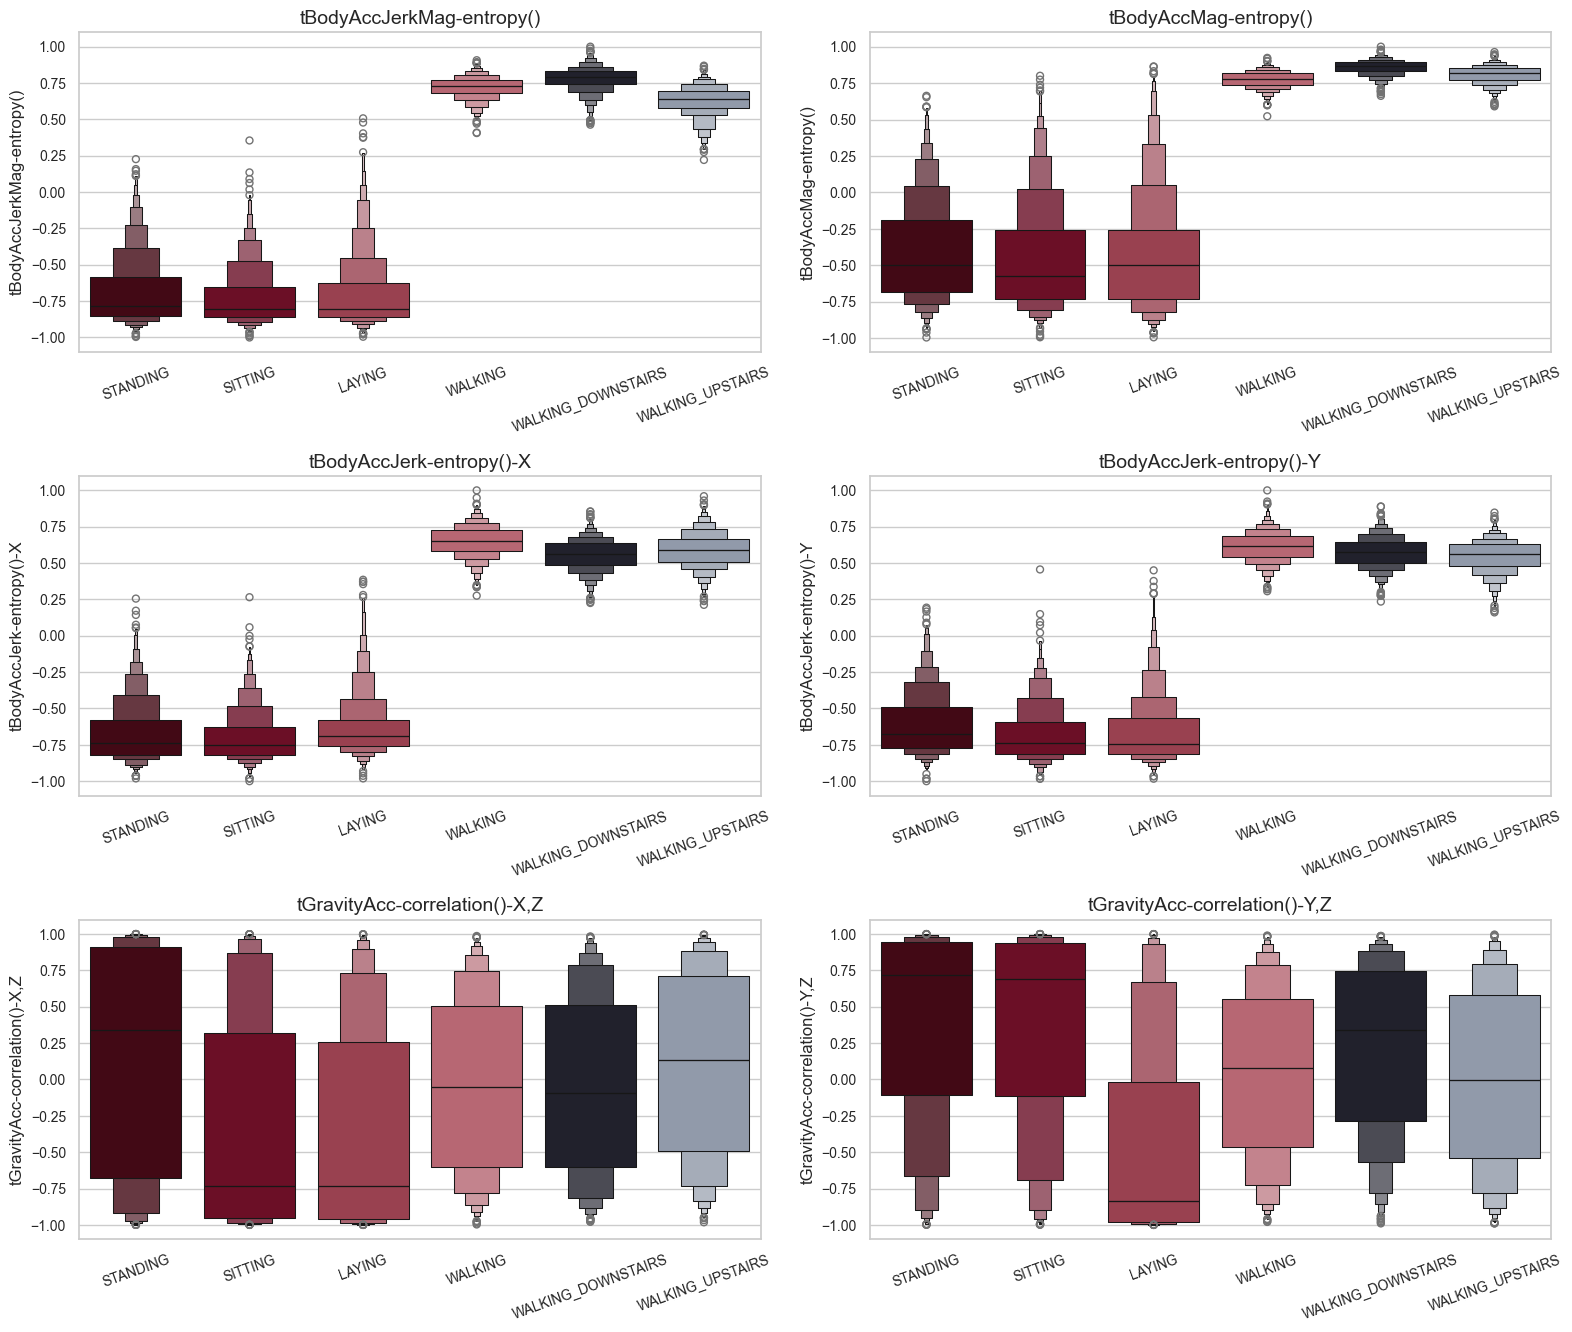

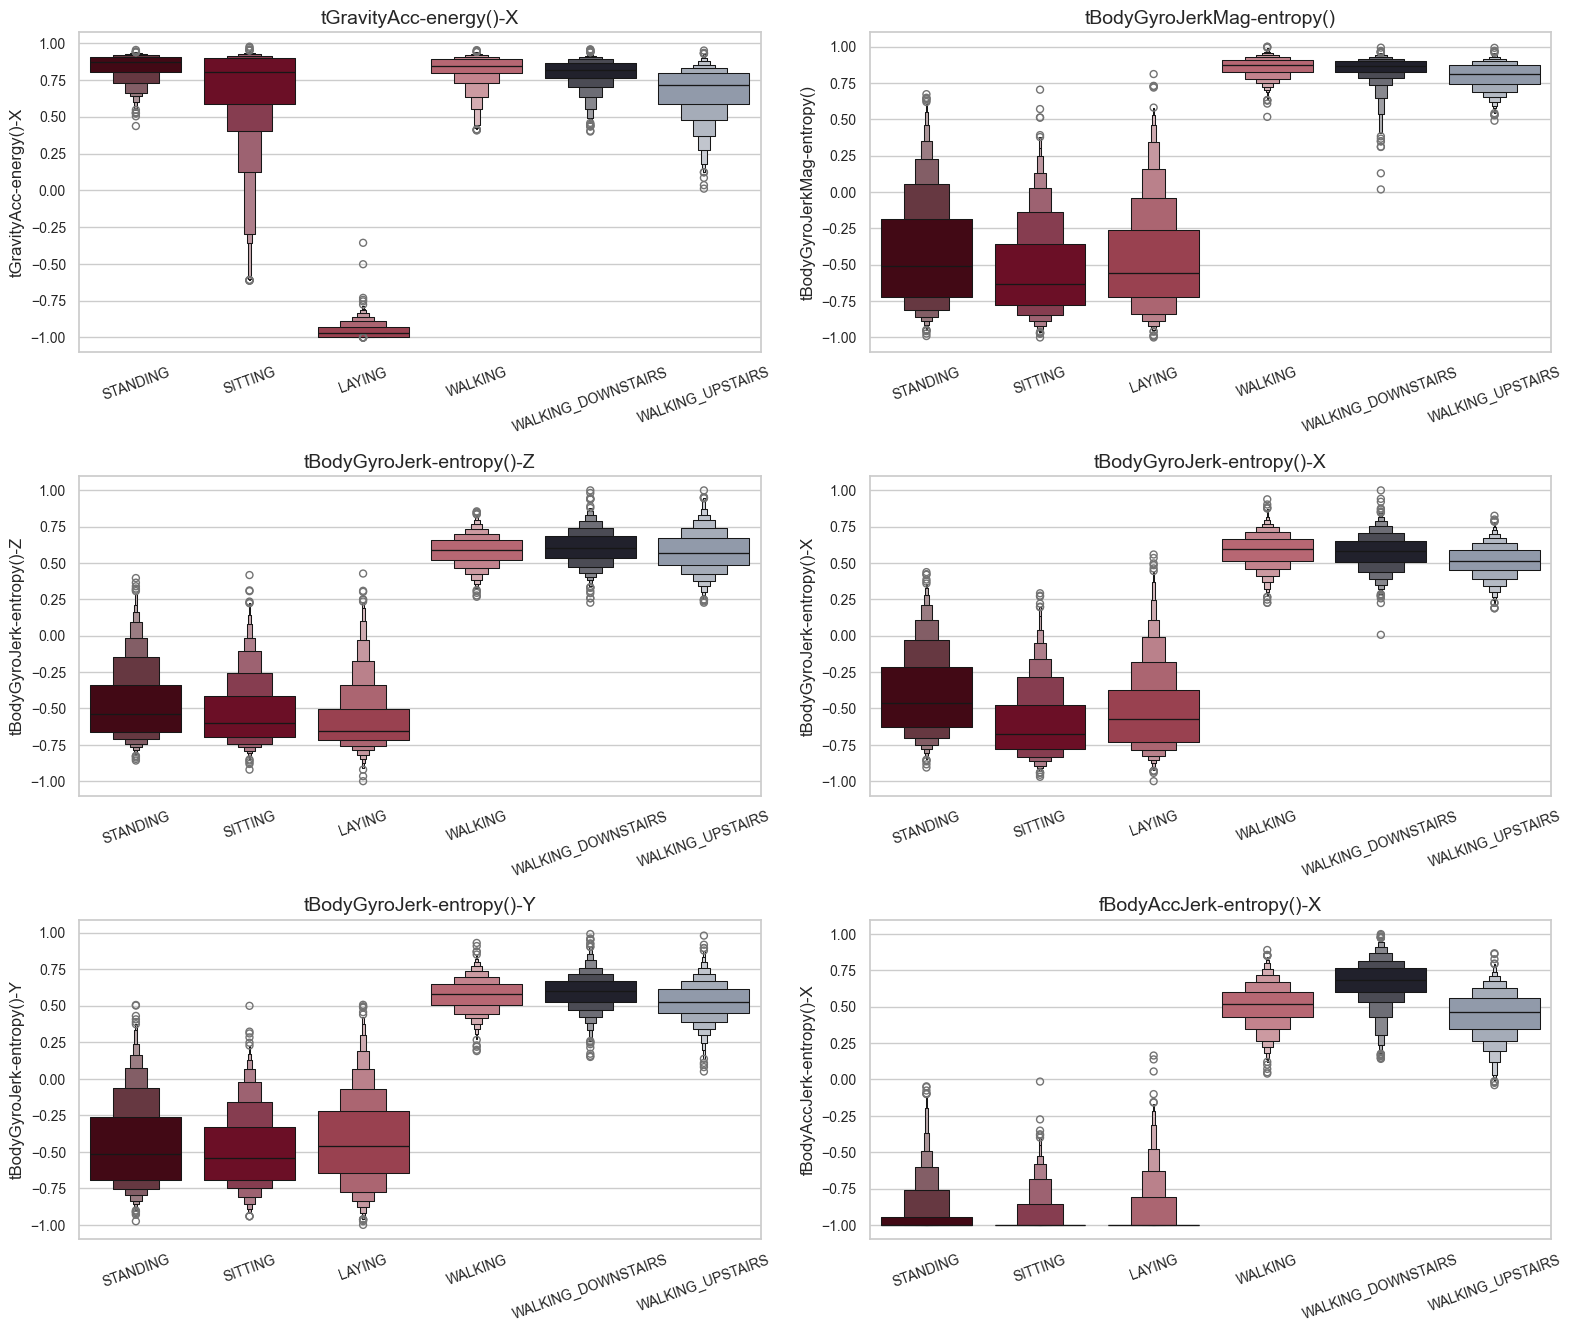

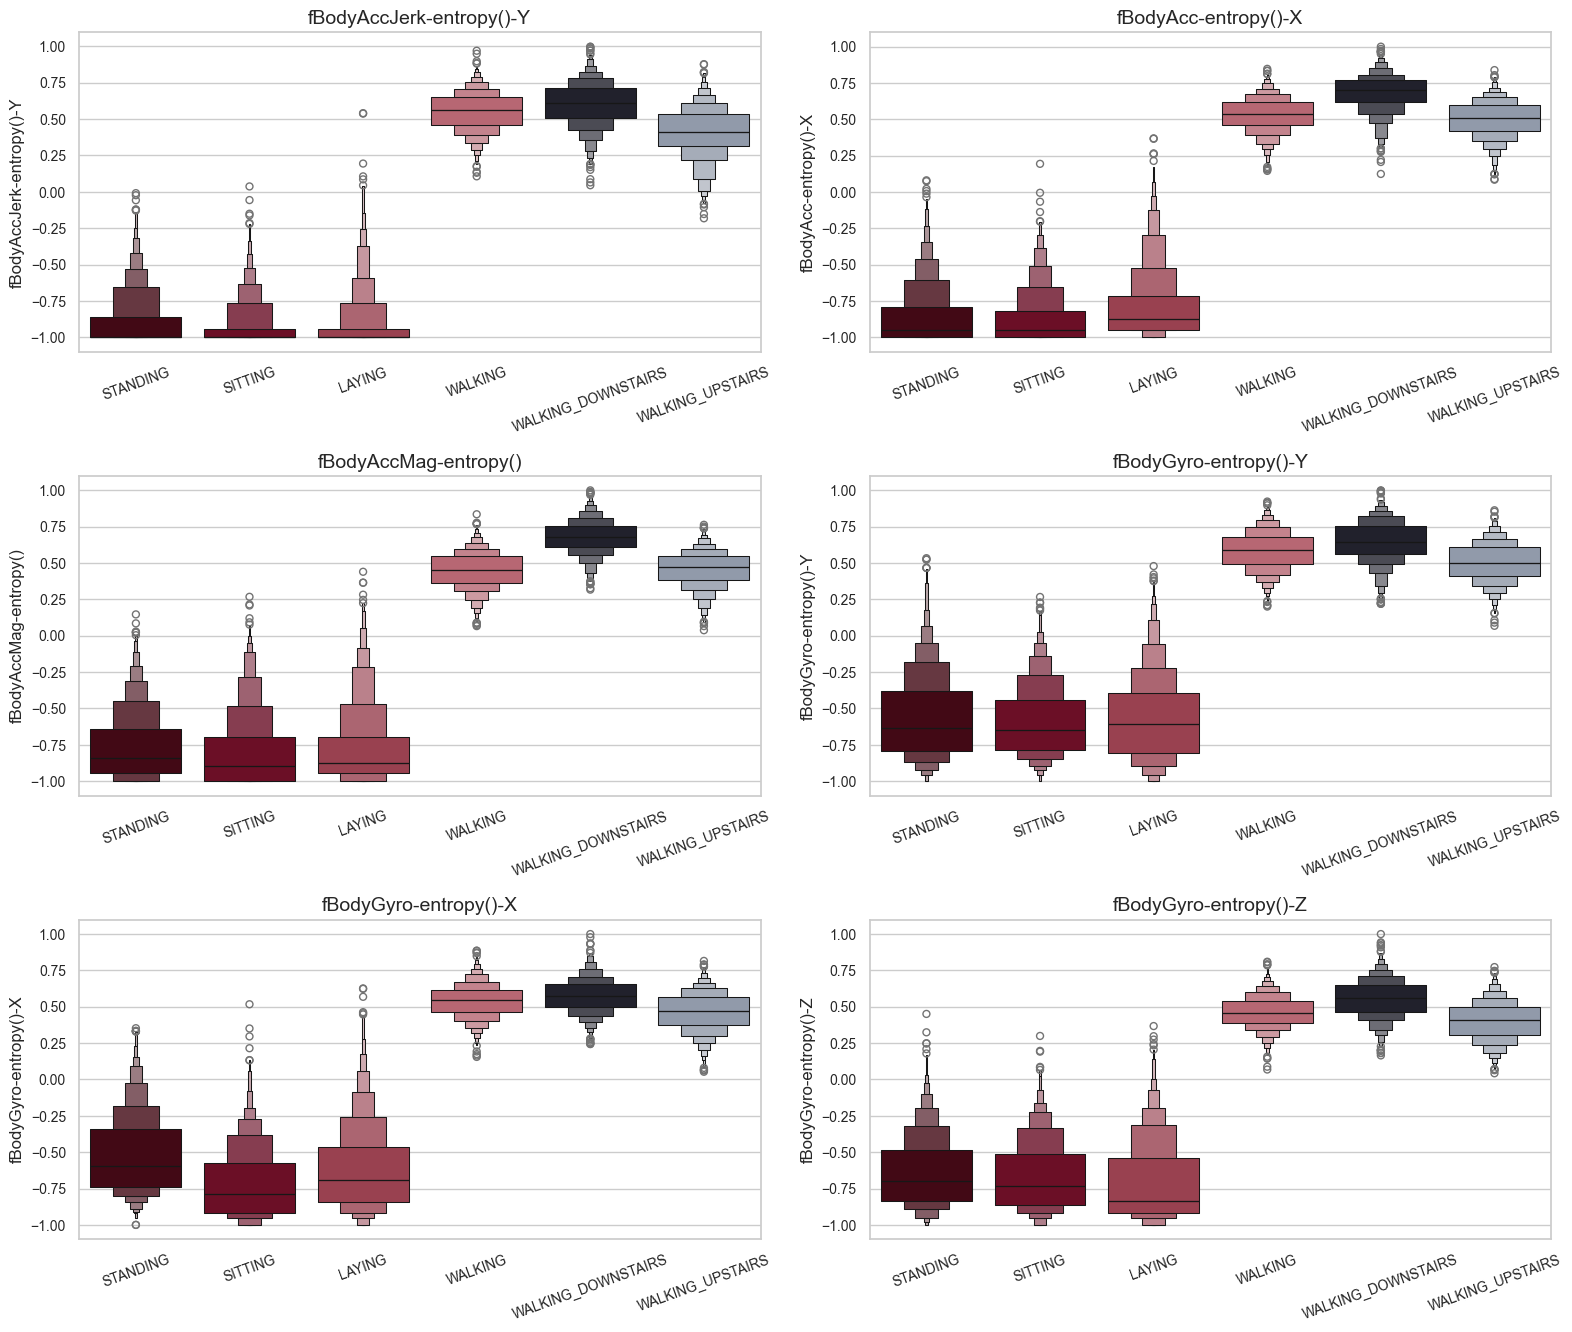

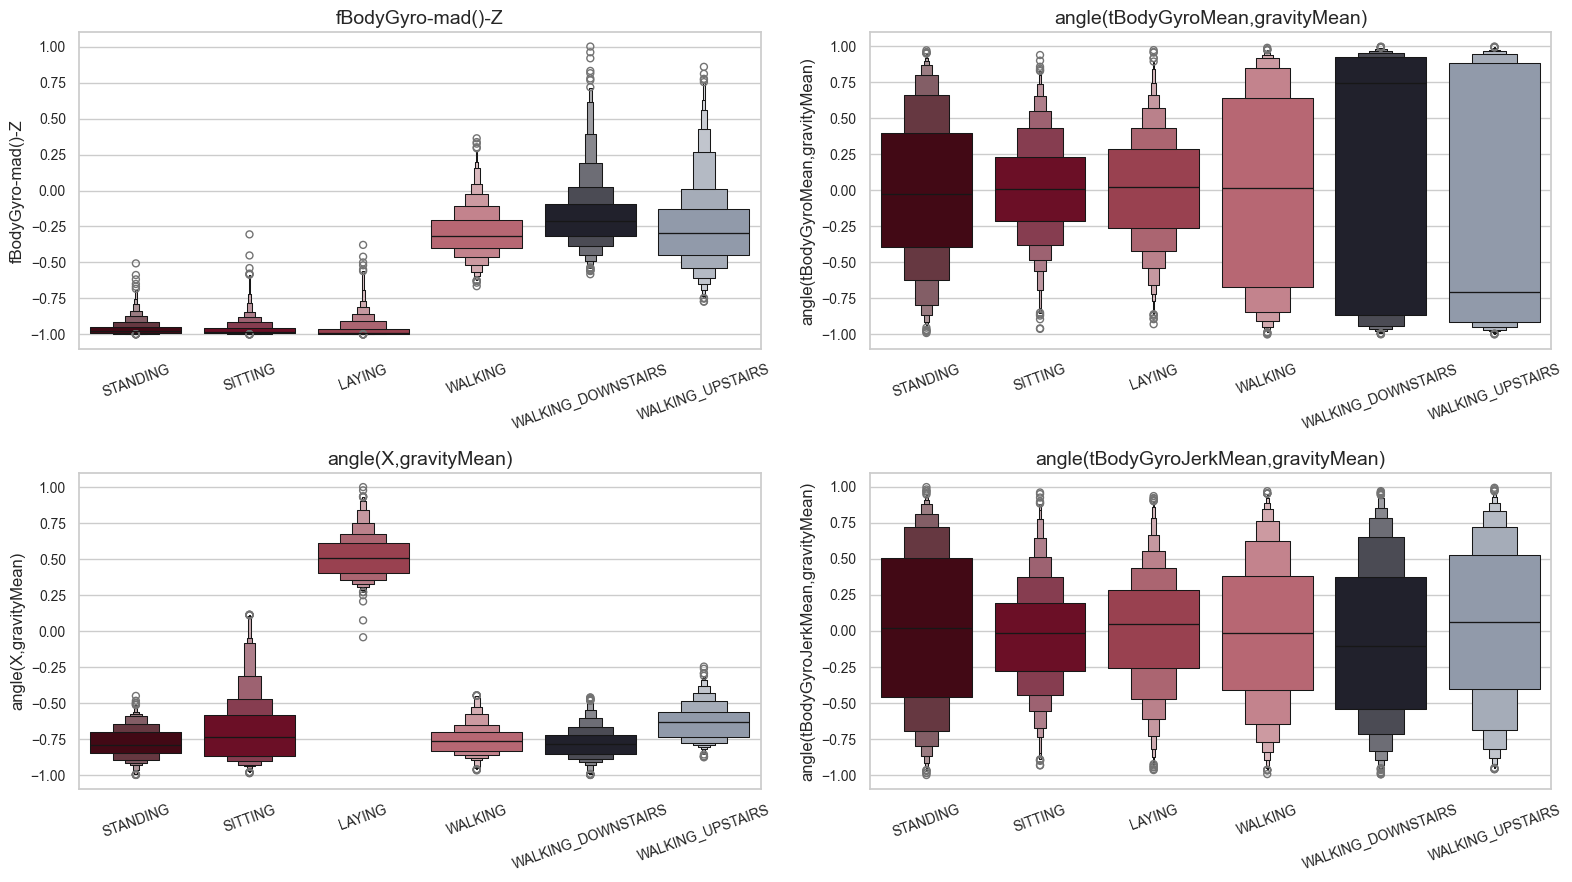

In [19]:
def plot_activity_feature_blocks(dataframe, features, chunk_size=6, kind="boxen"):
    palette = dark_palette[:dataframe["Activity"].nunique()]

    if kind == "boxen":
        plot_function = sns.boxenplot
    elif kind == "box":
        plot_function = sns.boxplot
    else:
        plot_function = sns.violinplot

    for block_start in range(0, len(features), chunk_size):
        feature_block = features[block_start:block_start + chunk_size]
        n_cols = 2
        n_rows = int(np.ceil(len(feature_block) / n_cols))

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4.5 * n_rows))
        axes = np.atleast_1d(axes).flatten()

        for ax, feature in zip(axes, feature_block):
            plot_function(
                data=dataframe,
                x="Activity",
                y=feature,
                hue="Activity",
                palette=palette,
                legend=False,
                ax=ax,
            )
            ax.set_title(feature)
            ax.set_xlabel("")
            ax.tick_params(axis="x", rotation=20)

        for ax in axes[len(feature_block):]:
            ax.axis("off")

        plt.tight_layout()
        plt.show()

plot_activity_feature_blocks(df, expanded_features, chunk_size=6, kind="boxen")

1. `LAYING` apresenta um perfil bastante distinto das demais atividades
   - isso aparece com mais clareza em variáveis relacionadas à gravidade e à orientação corporal, como `tGravityAcc-mean()-Y`, `tGravityAcc-energy()-X` e `angle(X,gravityMean)`
   - esse comportamento sugere que `LAYING` tende a ser uma das classes mais fáceis de diferenciar, porque a postura deitada gera um padrão de sensores bem diferente das demais

2. as atividades estáticas e dinâmicas formam blocos relativamente bem separados
   - atividades estáticas:
     - `LAYING`
     - `SITTING`
     - `STANDING`
   - atividades dinâmicas:
     - `WALKING`
     - `WALKING_DOWNSTAIRS`
     - `WALKING_UPSTAIRS`
   - essa separação aparece em várias features, especialmente nas ligadas à entropia, aceleração e giroscópio, indicando que essas variáveis ajudam a distinguir baixo movimento de movimento ativo

3. `SITTING` e `STANDING` continuam bastante parecidas em várias distribuições
   - em diversas features, essas duas classes aparecem com forte sobreposição
   - isso sugere que essa pode ser uma das separações mais difíceis para os modelos na etapa de classificação

4. as três atividades de caminhada compartilham padrões semelhantes, mas ainda apresentam diferenças úteis
   - em várias features de entropia, `WALKING`, `WALKING_DOWNSTAIRS` e `WALKING_UPSTAIRS` ficam claramente separadas do bloco estático
   - ao mesmo tempo, existe proximidade entre elas, o que indica que o modelo provavelmente terá mais facilidade para identificar o grupo de caminhada do que para distinguir perfeitamente cada tipo de caminhada

5. algumas features parecem menos discriminativas quando analisadas isoladamente
   - por exemplo, `tBodyAcc-mean()-X` varia pouco entre as classes
   - isso sugere que essa variável, sozinha, tem menor poder de separação, embora ainda possa contribuir quando combinada com outras features

6. variáveis relacionadas à gravidade, postura e orientação corporal parecem especialmente importantes
   - colunas como `tGravityAcc-mean()-Y`, `tGravityAcc-energy()-X` e `angle(X,gravityMean)` mudam bastante entre as atividades
   - esse padrão reforça que informações de postura são muito úteis para diferenciar atividades como deitar, sentar e ficar em pé

7. as variáveis de entropia parecem especialmente informativas para distinguir atividades dinâmicas e estáticas
   - de forma geral, `STANDING`, `SITTING` e `LAYING` tendem a se concentrar em valores mais baixos, enquanto as atividades de caminhada aparecem em faixas mais altas
   - isso sugere que medidas de entropia capturam bem a complexidade e a intensidade do movimento

## análise de correlação

datasets derivados de sensores costumam concentrar muitas variáveis correlacionadas. para evitar um heatmap com informações excessivas, selecionei as features com maior variância para calcular a matriz de correlação e destacar pares com correlação muito alta

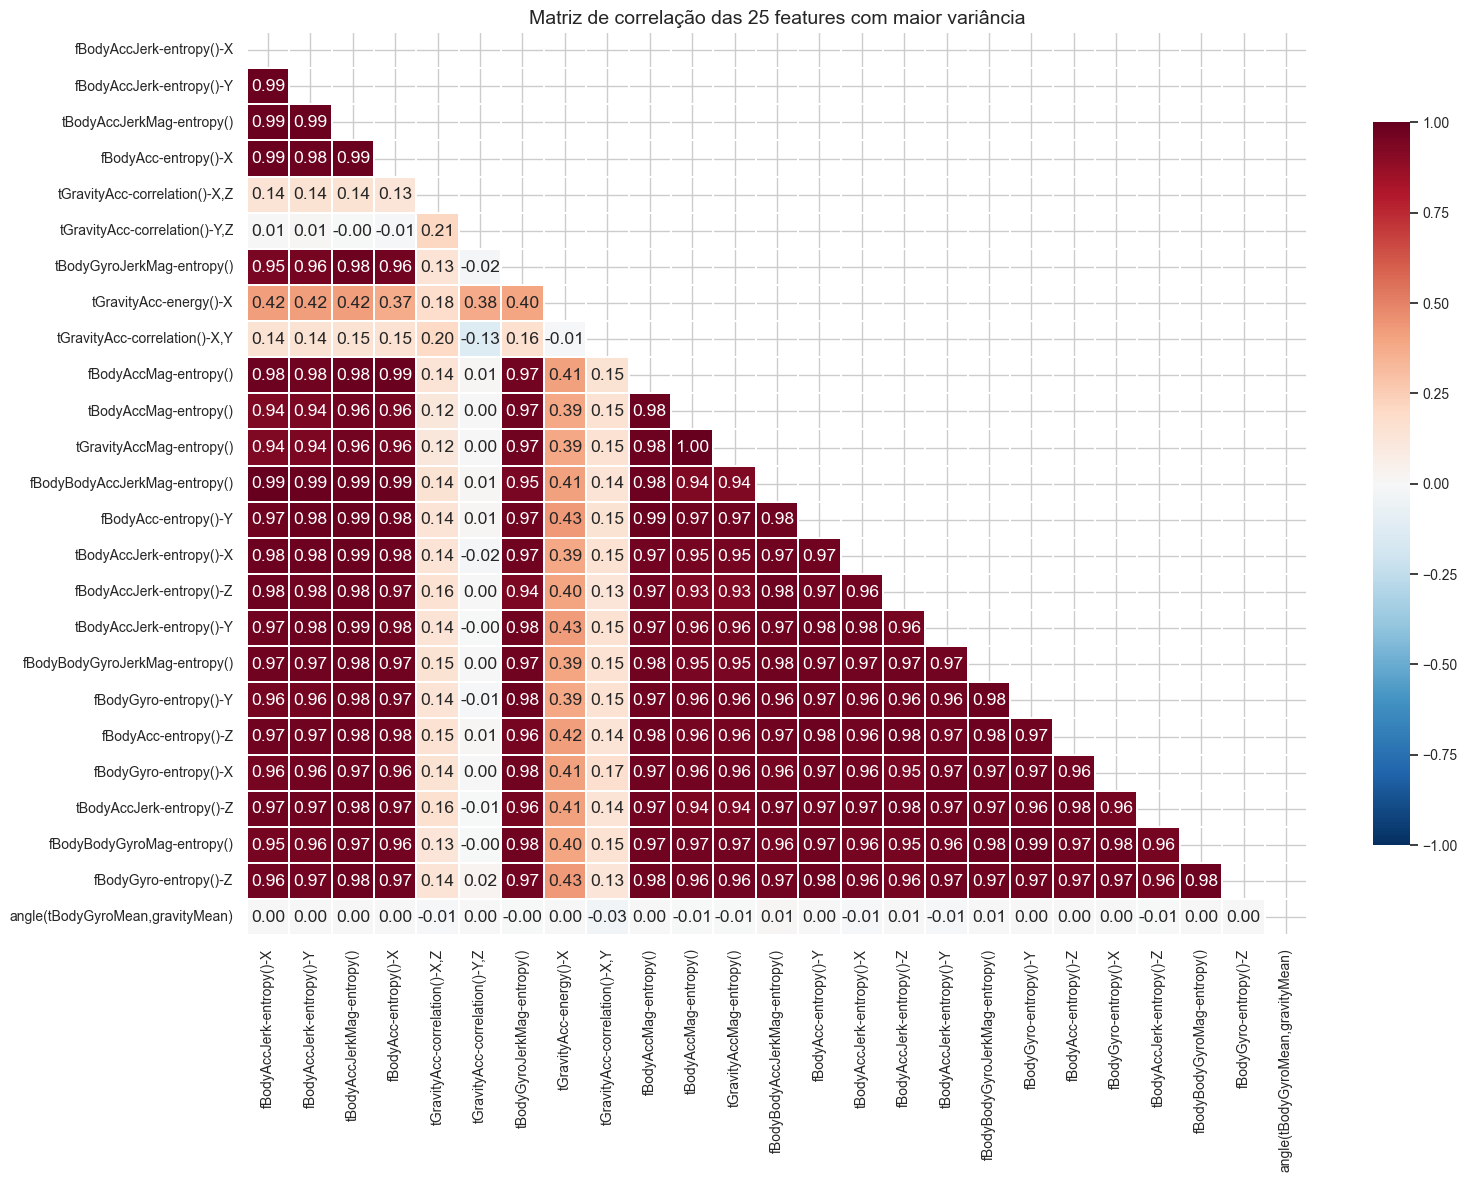

In [20]:
variance_ranking = df[numeric_features].var().sort_values(ascending=False)
top_variance_features = variance_ranking.head(25).index.tolist()

corr_matrix = df[top_variance_features].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap="RdBu_r",
    annot=True,
    fmt=".2f",
    vmin=-1,
    vmax=1,
    center=0,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
    square=False
)
plt.title("Matriz de correlação das 25 features com maior variância")
plt.tight_layout()
plt.show()

a matriz de correlação mostra que várias das 25 features com maior variância apresentam correlações muito altas, muitas delas acima de 0.95. isso sugere forte redundância entre parte das variáveis, algo esperado em datasets de sensores com muitas features derivadas de um mesmo sinal. em especial, medidas ligadas a entropia, magnitude e versões semelhantes calculadas em diferentes eixos tendem a carregar informações muito parecidas. esse padrão indica que a base é rica em informação, mas também bastante redundante, o que pode impactar modelos mais sensíveis à multicolinearidade e reforça a utilidade de técnicas como regularização, seleção de variáveis ou redução de dimensionalidade

- existe um bloco grande de correlações altas, muitas variáveis estão quase medindo a mesma coisa
- várias features vêm do mesmo sinal base, só mudando eixo, magnitude ou forma de cálculo
- nem toda feature adiciona informação nova, algumas podem ser redundantes
- obs. para modelagem:
    - modelos lineares podem sofrer com multicolinearidade
    - regularização pode ajudar
    - PCA ou seleção de features pode ser útil em versões futuras

### anotações mentoria
- plotar mais variáveis
- plotar correlação com a target
- criar função para variáveis com maior correlação com a target. no caso, selecionar apenas uma das que tiverem correlaçao maior entre si, acima de 70

In [21]:
corr_abs = corr_matrix.abs()
high_corr_pairs = []

for i, feature_1 in enumerate(corr_abs.columns):
    for j, feature_2 in enumerate(corr_abs.columns):
        if j > i and corr_abs.iloc[i, j] > 0.95:
            high_corr_pairs.append((feature_1, feature_2, corr_abs.iloc[i, j]))

high_corr_df = pd.DataFrame(high_corr_pairs, columns=["feature_1", "feature_2", "correlation"])
high_corr_df = high_corr_df.sort_values("correlation", ascending=False)

print(f"Quantidade de pares com correlação acima de 0.95 entre as 25 features selecionadas: {len(high_corr_df)}")
display(high_corr_df.head(15))

Quantidade de pares com correlação acima de 0.95 entre as 25 features selecionadas: 177


,feature_1,feature_2,correlation
93,tBodyAccMag-entropy(),tGravityAccMag-entropy(),1.000000
5,fBodyAccJerk-entropy()-X,fBodyBodyAccJerkMag-entropy(),0.992583
2,fBodyAccJerk-entropy()-X,fBodyAcc-entropy()-X,0.989862
17,fBodyAccJerk-entropy()-Y,tBodyAccJerkMag-entropy(),0.989667
33,tBodyAccJerkMag-entropy(),fBodyAcc-entropy()-X,0.989133
0,fBodyAccJerk-entropy()-X,fBodyAccJerk-entropy()-Y,0.988666
21,fBodyAccJerk-entropy()-Y,fBodyBodyAccJerkMag-entropy(),0.988162
1,fBodyAccJerk-entropy()-X,tBodyAccJerkMag-entropy(),0.988029
42,tBodyAccJerkMag-entropy(),tBodyAccJerk-entropy()-Y,0.987842
39,tBodyAccJerkMag-entropy(),fBodyAcc-entropy()-Y,0.987382


/var/folders/7z/wbm1wwyx7c725wqb3_cdkbm80000gn/T/ipykernel_67535/2190067140.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/var/folders/7z/wbm1wwyx7c725wqb3_cdkbm80000gn/T/ipykernel_67535/2190067140.py:5: UserWarning: 
The palette list has fewer values (7) than needed (15) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


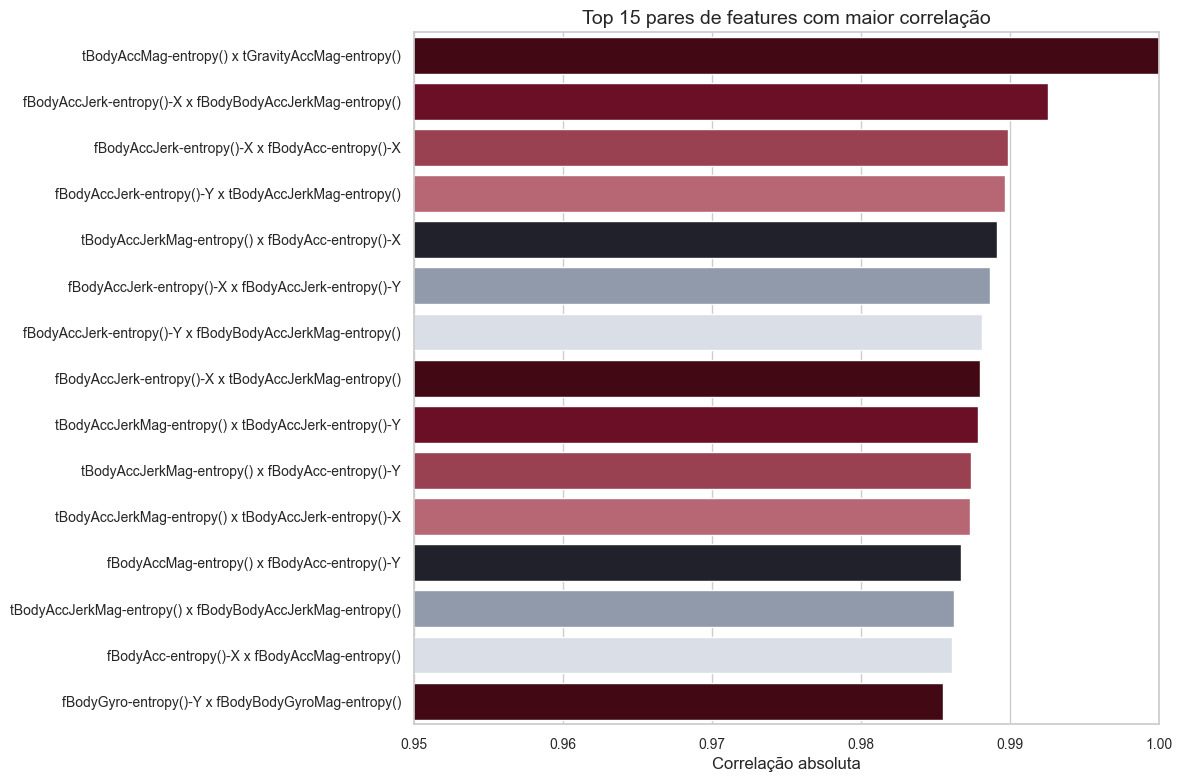

In [22]:
top_corr_pairs = high_corr_df.head(15).copy()
top_corr_pairs["pair"] = top_corr_pairs["feature_1"] + " x " + top_corr_pairs["feature_2"]

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_corr_pairs,
    y="pair",
    x="correlation",
    palette=dark_palette[:len(top_corr_pairs)]
)
plt.title("Top 15 pares de features com maior correlação")
plt.xlabel("Correlação absoluta")
plt.ylabel("")
plt.xlim(0.95, 1.0)
plt.tight_layout()
plt.show()

os 15 pares mais correlacionados apresentam correlações extremamente altas, todas acima de aproximadamente 0.985, o que reforça a existência de forte redundância entre várias features derivadas dos sensores. em especial, variáveis ligadas a entropia, magnitude e versões semelhantes calculadas em diferentes eixos ou domínios aparecem repetidamente entre os pares mais fortes, sugerindo que parte dessas colunas carrega informações muito parecidas

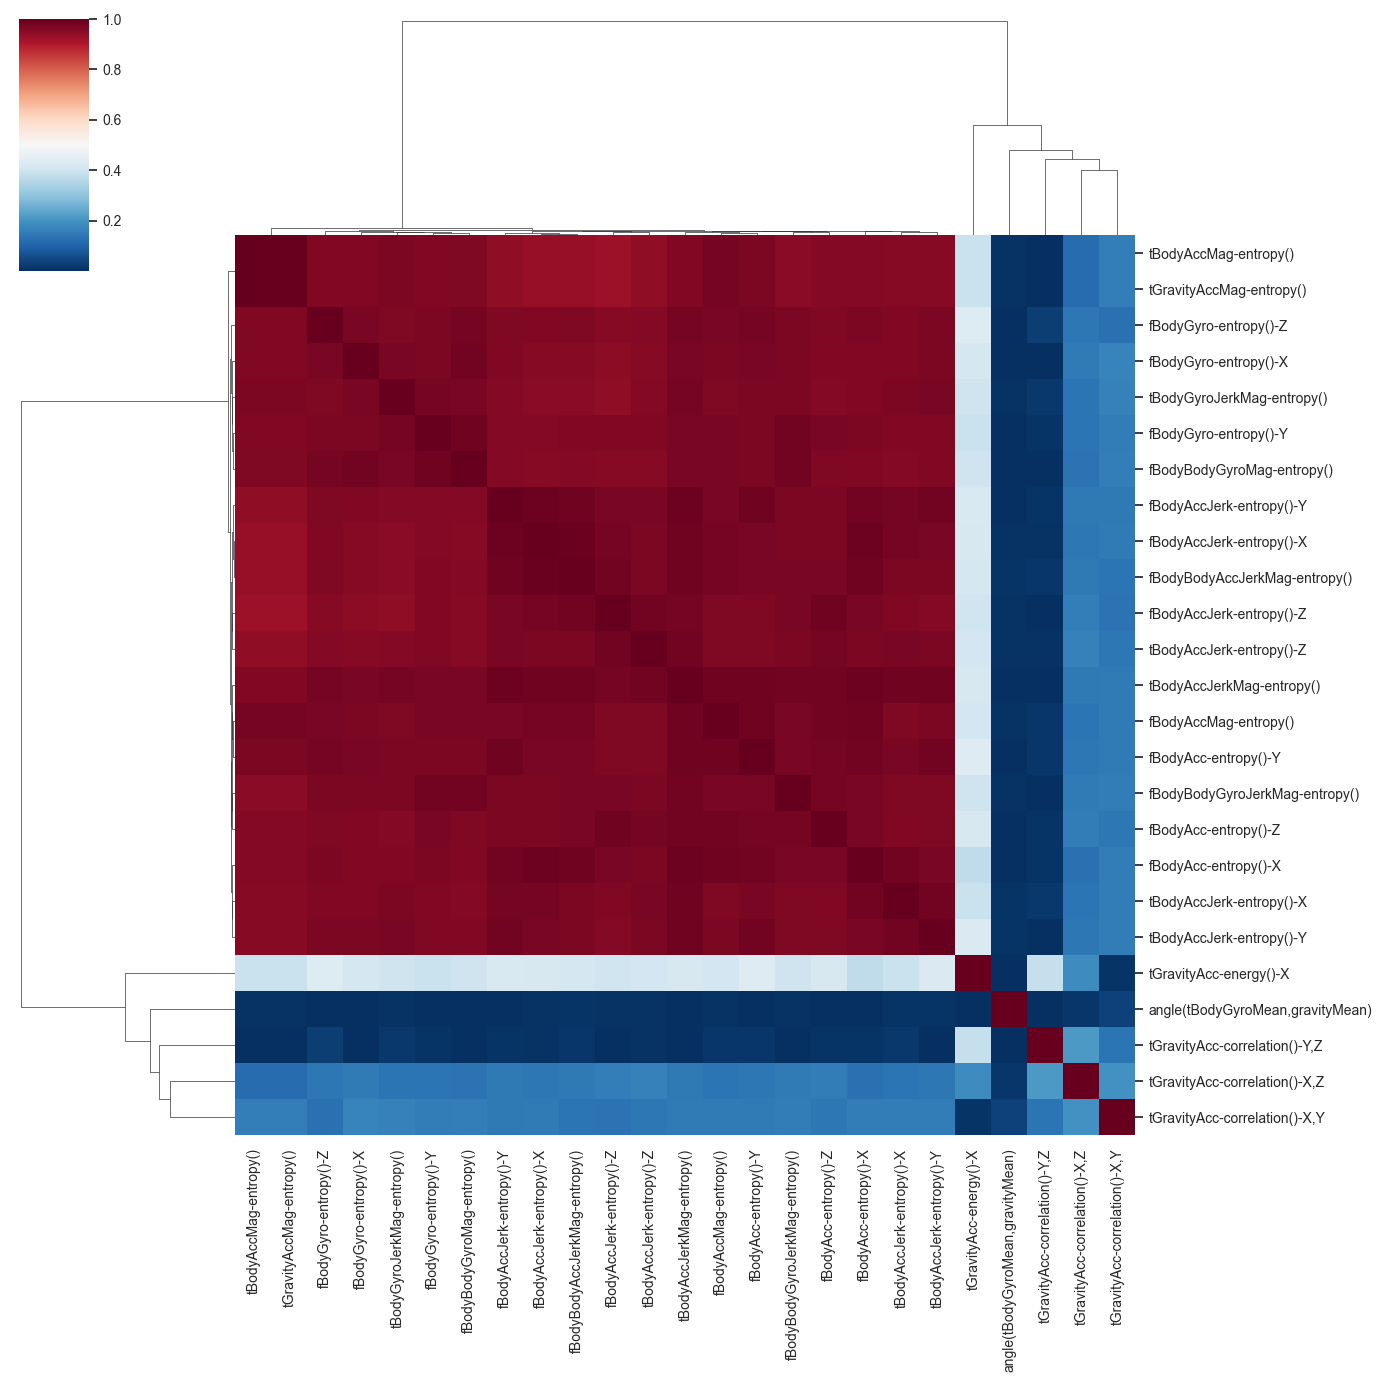

In [23]:
sns.clustermap(
    corr_matrix.abs(),
    cmap="RdBu_r",
    figsize=(14, 14)
)

## correlação das features com a target

medir o quanto cada variável se associa à coluna `Activity`.

como `Activity` é categórica, primeiro vamos criar uma versão codificada com `LabelEncoder`. essa etapa serve apenas para exploração, pois ao transformar classes em números, criamos uma ordem artificial entre categorias que, na prática, não têm hierarquia natural

essa correlação com a target ajuda a levantar hipóteses sobre variáveis promissoras, mas não deve ser interpretada como causalidade nem como uma verdade definitiva sobre importância das features

In [24]:
from sklearn.preprocessing import LabelEncoder

activity_encoder = LabelEncoder()
y_encoded = pd.Series(
    activity_encoder.fit_transform(df["Activity"]),
    index=df.index,
    name="Activity_encoded"
)

activity_mapping_df = pd.DataFrame(
    {
        "atividade": activity_encoder.classes_,
        "codigo": range(len(activity_encoder.classes_)),
    }
)

display(activity_mapping_df)

,atividade,codigo
0,LAYING,0
1,SITTING,1
2,STANDING,2
3,WALKING,3
4,WALKING_DOWNSTAIRS,4
5,WALKING_UPSTAIRS,5


In [33]:
def select_features_by_corr(
    features_df,
    target_encoded,
    inter_feature_corr_threshold=0.70,
    top_n=None,
    method="pearson",
):
    target_series = pd.Series(target_encoded, index=features_df.index, name="target_encoded")

    target_corr = (
        features_df.apply(lambda col: col.corr(target_series, method=method))
        .abs()
        .fillna(0.0)
    )

    ranking_df = (
        target_corr.sort_values(ascending=False)
        .rename("target_corr_abs")
        .rename_axis("feature")
        .reset_index()
    )

    feature_corr_matrix = features_df.corr(method=method).abs()
    target_corr_map = dict(zip(ranking_df["feature"], ranking_df["target_corr_abs"]))

    selected_features = []
    removed_records = []

    for feature in ranking_df["feature"]:
        redundant_with = None
        inter_feature_corr = None

        for selected_feature in selected_features:
            corr_value = feature_corr_matrix.loc[feature, selected_feature]

            if pd.notna(corr_value) and corr_value > inter_feature_corr_threshold:
                redundant_with = selected_feature
                inter_feature_corr = corr_value
                break

        if redundant_with is None:
            selected_features.append(feature)
        else:
            removed_records.append(
                {
                    "feature_removida": feature,
                    "target_corr_abs": target_corr_map[feature],
                    "feature_mantida": redundant_with,
                    "target_corr_abs_mantida": target_corr_map[redundant_with],
                    "correlacao_entre_features": inter_feature_corr,
                }
            )

    if top_n is not None:
        selected_features = selected_features[:top_n]

    removed_df = (
        pd.DataFrame(removed_records)
        .sort_values(
            ["correlacao_entre_features", "target_corr_abs"],
            ascending=[False, False]
        )
        .reset_index(drop=True)
    )

    return selected_features, ranking_df, removed_df

### aplicando a seleção de variáveis não redundantes

aplicação de uma função nas variáveis numéricas do dataset. a ideia é selecionar as features que parecem ter maior relação com a target, mas sem manter várias variáveis que carregam praticamente a mesma informação

para isso, considerei dois critérios:

1. priorizar as variáveis com maior correlação com a target codificada
2. quando duas ou mais features tiverem correlação acima de 70% entre si, vou manter apenas aquela que tiver maior correlação com a target

como a coluna `subject` representa apenas o identificador do participante, e não uma medida capturada pelos sensores, vou deixá-la fora desta etapa. assim, a análise fica focada nas features derivadas do acelerômetro e do giroscópio

In [38]:
feature_df_for_target_corr = df[numeric_features].copy()

selected_features_all, target_corr_ranking_df, removed_by_redundancy_df = select_features_by_corr(
    feature_df_for_target_corr,
    y_encoded,
    inter_feature_corr_threshold=0.70,
    top_n=None,
    method="pearson",
)

selected_feature_ranking_df = (
    target_corr_ranking_df[target_corr_ranking_df["feature"].isin(selected_features_all)]
    .copy()
    .reset_index(drop=True)
)

selection_summary_df = pd.DataFrame(
    {
        "metrica": [
            "Quantidade inicial de features numéricas",
            "Quantidade final de features selecionadas",
            "Quantidade removida por redundância",
        ],
        "valor": [
            feature_df_for_target_corr.shape[1],
            len(selected_features_all),
            len(removed_by_redundancy_df),
        ],
    }
)

display(selection_summary_df)
display(selected_feature_ranking_df.head(15))
display(removed_by_redundancy_df.head(15))

,metrica,valor
0,Quantidade inicial de features numéricas,561
1,Quantidade final de features selecionadas,140
2,Quantidade removida por redundância,421


,feature,target_corr_abs
0,fBodyAccJerk-entropy()-X,0.845190
1,tGravityAcc-min()-Y,0.749414
2,"fBodyAcc-bandsEnergy()-1,8.2",0.660492
3,"tBodyGyro-arCoeff()-Z,1",0.642150
4,tGravityAcc-min()-Z,0.631560
5,fBodyAccJerk-meanFreq()-Z,0.618574
6,"tBodyAccJerk-arCoeff()-Y,1",0.605988
7,"fBodyGyro-bandsEnergy()-1,8",0.577606
8,tBodyAccJerkMag-arCoeff()1,0.575811
9,"tBodyGyro-arCoeff()-X,1",0.553514


,feature_removida,target_corr_abs,feature_mantida,target_corr_abs_mantida,correlacao_entre_features
0,tBodyAccMag-arCoeff()1,0.525731,tGravityAccMag-arCoeff()1,0.525731,1.000000
1,tBodyAccMag-arCoeff()3,0.357193,tGravityAccMag-arCoeff()3,0.357193,1.000000
2,tGravityAcc-mad()-Z,0.138240,tGravityAcc-std()-Z,0.140106,0.998622
3,tGravityAcc-mean()-Z,0.625985,tGravityAcc-min()-Z,0.631560,0.996446
4,tGravityAcc-mean()-Y,0.748398,tGravityAcc-min()-Y,0.749414,0.996399
5,"fBodyAccJerk-bandsEnergy()-49,64.1",0.503807,"fBodyAccJerk-bandsEnergy()-49,56.1",0.503917,0.996364
6,"tGravityAcc-arCoeff()-Z,3",0.194024,"tGravityAcc-arCoeff()-Z,4",0.236423,0.994256
7,fBodyBodyAccJerkMag-entropy(),0.829260,fBodyAccJerk-entropy()-X,0.845190,0.992583
8,"angle(Z,gravityMean)",0.611528,tGravityAcc-min()-Z,0.631560,0.990991
9,"angle(Y,gravityMean)",0.725408,tGravityAcc-min()-Y,0.749414,0.990047


a seleção reduziu bastante o número de variáveis analisadas sendo que das 561 features numéricas iniciais, 140 foram mantidas e 421 foram removidas por redundância

isso mostra que a base possui muitas variáveis muito parecidas entre si, o que faz sentido, já que várias features foram criadas a partir de transformações dos mesmos sinais de sensores

entre as variáveis mantidas, aparecem medidas ligadas a entropia, gravidade, bandas de energia e coeficientes derivados dos sinais, indicando que esses grupos podem ser mais úteis para diferenciar as atividades

a tabela de variáveis removidas reforça essa redundância, já que várias features descartadas tinham correlação muito alta com variáveis mantidas, em alguns casos próxima de 1.0

In [39]:
def map_feature_family(feature_name):
    if feature_name.startswith("tBodyAcc"):
        return "tBodyAcc"
    if feature_name.startswith("tGravityAcc"):
        return "tGravityAcc"
    if feature_name.startswith("tBodyGyro"):
        return "tBodyGyro"
    if feature_name.startswith("fBodyAcc"):
        return "fBodyAcc"
    if feature_name.startswith("fBodyGyro"):
        return "fBodyGyro"
    if feature_name.startswith("angle"):
        return "angle"
    return "outras"

selected_family_distribution_df = (
    selected_feature_ranking_df.head(30)["feature"]
    .map(map_feature_family)
    .value_counts()
    .rename_axis("familia")
    .reset_index(name="quantidade_no_top_30")
)

display(selected_family_distribution_df)

,familia,quantidade_no_top_30
0,fBodyAcc,12
1,tBodyGyro,7
2,tGravityAcc,4
3,fBodyGyro,4
4,tBodyAcc,3


- entre as 30 features mais correlacionadas com a target, a família `fBodyAcc` aparece com maior frequência, o que sugere que medidas de aceleração no domínio da frequência são especialmente úteis para diferenciar as atividades

- a presença de várias features da família `tBodyGyro` mostra que informações ligadas à rotação corporal também têm papel importante na separação das classes

- as variáveis da família `tGravityAcc`, mesmo em menor número, continuam relevantes, reforçando que postura e orientação corporal ajudam bastante a distinguir atividades estáticas

- no conjunto, a distribuição das famílias sugere que o problema depende de diferentes tipos de sinal, algumas features capturam intensidade e padrão de movimento, enquanto outras representam postura, gravidade e rotação

- isso indica que a classificação das atividades não depende de uma única família de variáveis, mas sim da combinação entre medidas no domínio do tempo, da frequência e da orientação corporal

/var/folders/7z/wbm1wwyx7c725wqb3_cdkbm80000gn/T/ipykernel_67535/2492786391.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


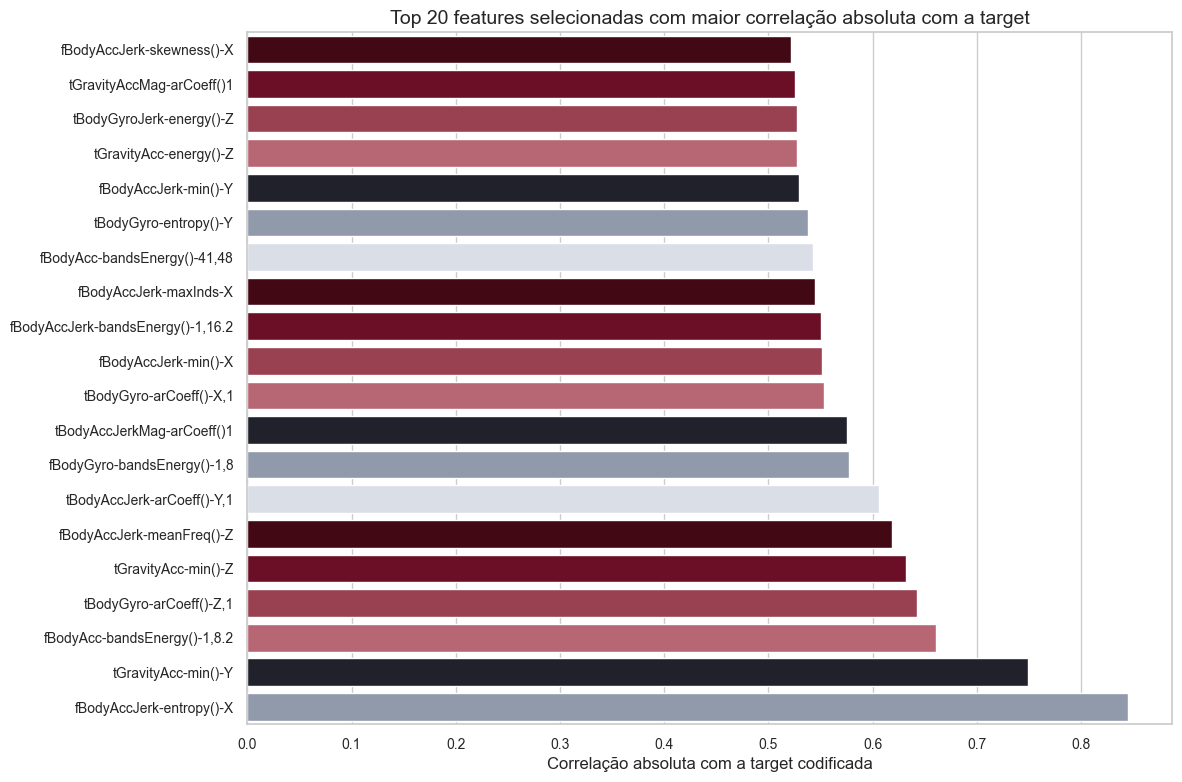

In [40]:
top_selected_target_corr_df = selected_feature_ranking_df.head(20).copy()
plot_palette = [dark_palette[i % len(dark_palette)] for i in range(len(top_selected_target_corr_df))]

plt.figure(figsize=(12, 8))
sns.barplot(
    data=top_selected_target_corr_df.sort_values("target_corr_abs", ascending=True),
    y="feature",
    x="target_corr_abs",
    palette=plot_palette,
)
plt.title("Top 20 features selecionadas com maior correlação absoluta com a target")
plt.xlabel("Correlação absoluta com a target codificada")
plt.ylabel("")
plt.tight_layout()
plt.show()

- o gráfico destaca as 20 features selecionadas com maior correlação absoluta com a target, já após o filtro de redundância entre variáveis

- a feature `fBodyAccJerk-entropy()-X` aparece como a mais associada à target, sugerindo que medidas de entropia e complexidade do movimento têm forte poder discriminativo

- entre as variáveis mais relevantes aparecem diferentes famílias de features, como `fBodyAcc`, `tGravityAcc`, `tBodyGyro` e `fBodyGyro`, o que mostra que a classificação das atividades depende de múltiplos tipos de sinal

- variáveis relacionadas à gravidade, como `tGravityAcc-min()-Y` e `tGravityAcc-min()-Z`, reforçam a importância da postura e da orientação corporal, especialmente para distinguir atividades estáticas

- já features como `fBodyAccJerk-entropy()-X`, `fBodyAcc-bandsEnergy()-1,8.2` e `fBodyGyro-bandsEnergy()-1,8` indicam que medidas espectrais e de complexidade do movimento também são muito úteis para diferenciar atividades dinâmicas

- como essas features já passaram por uma etapa de remoção de redundância, esse ranking tende a destacar variáveis mais informativas sem repetir excessivamente o mesmo padrão de sinal

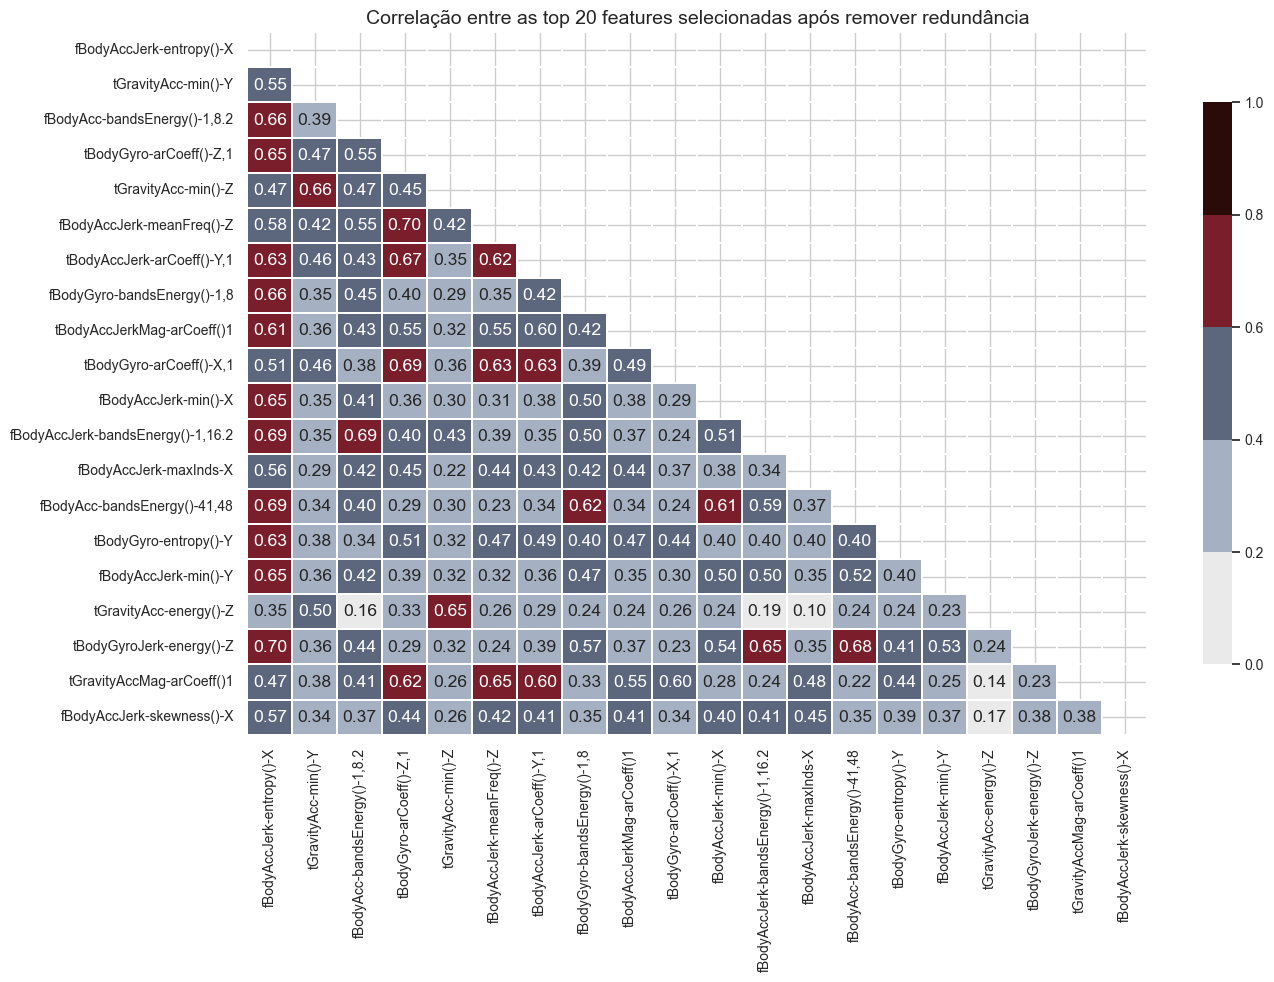

In [54]:
heatmap_features = selected_features_all[:20]
selected_corr_matrix = feature_df_for_target_corr[heatmap_features].corr().abs()
selected_mask = np.triu(np.ones_like(selected_corr_matrix, dtype=bool))

plt.figure(figsize=(14, 10))
sns.heatmap(
    selected_corr_matrix,
    mask=selected_mask,
    cmap=sns.color_palette(
    ["#EAEAEA","#A5B1C2", "#5C677D", "#7B1E2B", "#2B0A0A"],
    as_cmap=True
),
    vmin=0,
    vmax=1,
    annot=True,
    fmt=".2f",
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlação entre as top 20 features selecionadas após remover redundância")
plt.tight_layout()
plt.show()

- o heatmap mostra que, após a remoção de redundância, as features selecionadas ainda mantêm algumas correlações moderadas, mas sem repetir de forma tão intensa o mesmo padrão observado antes

- de modo geral, as correlações ficaram em níveis intermediários, o que sugere que a seleção conseguiu reduzir a redundância excessiva sem eliminar completamente relações naturais entre variáveis da mesma família

- isso indica que o conjunto final está mais equilibrado, suficientemente diverso para representar diferentes aspectos do movimento, mas sem tantas features quase duplicadas

### classes da target codificadas em one-hot

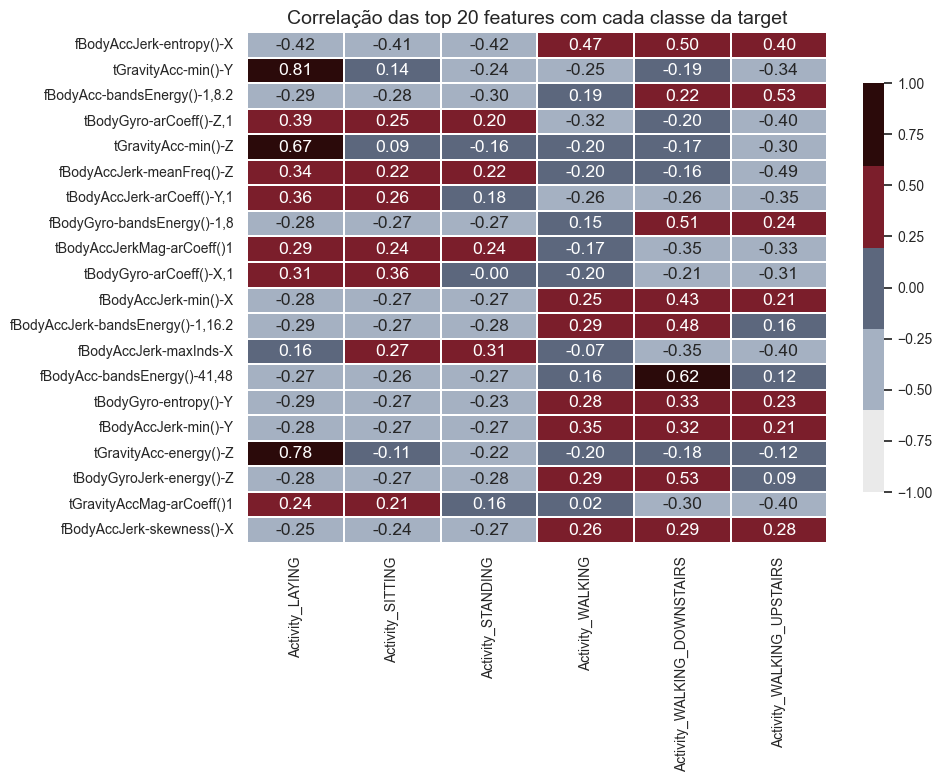

In [55]:
activity_dummies = pd.get_dummies(df["Activity"], prefix="Activity")

top_features = selected_feature_ranking_df.head(20)["feature"].tolist()

feature_target_matrix = pd.concat(
    [feature_df_for_target_corr[top_features], activity_dummies],
    axis=1
).corr()

heatmap_target = feature_target_matrix.loc[top_features, activity_dummies.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_target,
    annot=True,
    fmt=".2f",
    cmap=sns.color_palette(
        ["#EAEAEA","#A5B1C2", "#5C677D", "#7B1E2B", "#2B0A0A"],
        as_cmap=True
    ),
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.3,
    cbar_kws={"shrink": 0.8},
)
plt.title("Correlação das top 20 features com cada classe da target")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

- o heatmap mostra que as top features não se associam da mesma forma a todas as atividades, mas sim a classes específicas

- `LAYING` é a classe mais claramente destacada, principalmente por variáveis relacionadas à gravidade e à orientação corporal, o que reforça que postura é um fator importante para identificá-la

- entre as atividades dinâmicas, `WALKING_DOWNSTAIRS` aparece com associações positivas relativamente fortes em várias features, sugerindo um padrão de movimento mais característico

- já `SITTING` e `STANDING` continuam com perfis mais próximos, o que indica maior dificuldade de separação entre essas classes

- no conjunto, o gráfico sugere que atividades estáticas dependem mais de variáveis de postura e gravidade, enquanto atividades dinâmicas dependem mais de medidas de movimento, energia e frequência

## como essa análise pode orientar a modelagem

- **modelos lineares e KNN** tendem a sentir mais o efeito de redundância e escala, então um conjunto reduzido pode ajudar tanto no desempenho quanto na estabilidade
- **modelos baseados em árvore** costumam lidar melhor com muitas features, mas ainda assim podem se beneficiar de um conjunto menos redundante, principalmente para interpretação e custo computacional
- **seleção de variáveis** pode reduzir complexidade, tempo de treino e dificuldade de explicar o comportamento do modelo

## redução de dimensionalidade para visualização

como o número de features é muito alto, uma forma útil de inspecionar a estrutura dos dados é projetar as observações em duas dimensões com PCA (Principal Component Analysis, técnica usada para reduzir a dimensionalidade dos dados). aqui, o PCA é usado apenas para visualização, não como etapa obrigatória da modelagem

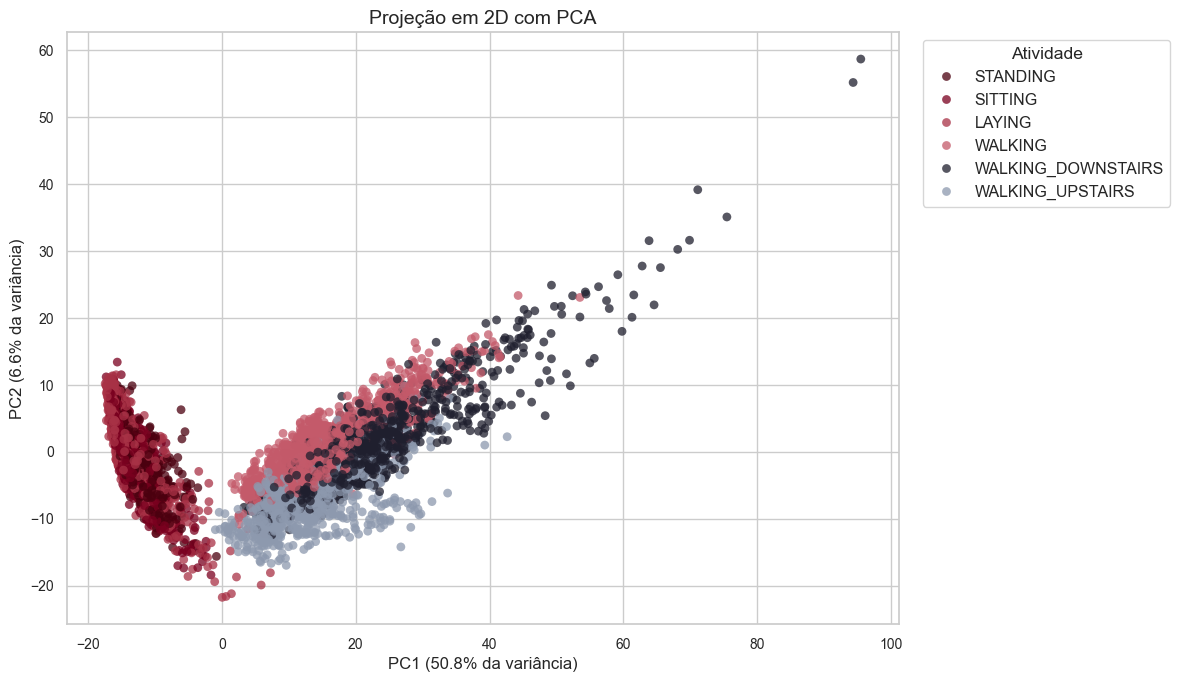

In [30]:
X = df.drop(columns=["Activity"])
if "subject" in X.columns:
    X = X.drop(columns=["subject"])
y = df["Activity"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "Activity": y
})

explained_variance = pca.explained_variance_ratio_

plt.figure(figsize=(12, 7))
sns.scatterplot(
    data=pca_df,
    x="PC1",
    y="PC2",
    hue="Activity",
    palette=dark_palette[:6],
    alpha=0.75,
    s=40,
    linewidth=0
)
plt.title("Projeção em 2D com PCA")
plt.xlabel(f"PC1 ({explained_variance[0] * 100:.1f}% da variância)")
plt.ylabel(f"PC2 ({explained_variance[1] * 100:.1f}% da variância)")
plt.legend(title="Atividade", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

a projeção em 2D com PCA mostra que os dados possuem estrutura e que parte das atividades forma agrupamentos relativamente distintos, especialmente entre padrões mais estáticos e mais dinâmicos. ainda assim, há sobreposição entre algumas classes, o que sugere que certas atividades compartilham características semelhantes e podem ser mais difíceis de separar. esse resultado reforça que o dataset contém sinal relevante para classificação, mas também indica que o problema não é totalmente trivial

explicação sobre PCA:

- PCA significa Principal Component Analysis. é uma técnica usada para reduzir a dimensionalidade dos dados
- nesse dataset, existem centenas de features. o PCA tenta resumir essa informação em poucas novas variáveis, chamadas de PC1 (direção que mais explica a variação dos dados), PC2 (segunda direção mais importante, independente da primeira), PC3, ...
- esses componentes não são colunas originais do dataset, mas sim combinações matemáticas das features originais, capturam a maior quantidade possível de variação dos dados

In [31]:
pca_centroids = pca_df.groupby("Activity")[["PC1", "PC2"]].mean().round(3)
display(pca_centroids)

,PC1,PC2
Activity,,
LAYING,-14.274,1.697
SITTING,-14.021,1.029
STANDING,-13.518,0.220
WALKING,15.795,1.028
WALKING_DOWNSTAIRS,23.806,2.121
WALKING_UPSTAIRS,12.910,-6.863


os dois primeiros componentes principais explicam aproximadamente 57.4% da variância total. em geral, atividades dinâmicas e estáticas tendem a se separar com mais clareza no eixo principal, enquanto classes parecidas ainda mantêm alguma sobreposição

## principais insights da análise exploratória

- o dataset de treino está bem estruturado, com 7352 linhas e 563 colunas, sem valores nulos nem duplicatas. isso permite concentrar a análise no comportamento das classes e nas relações entre as variáveis, sem necessidade de uma etapa extensa de limpeza

- a variável alvo `Activity` está relativamente equilibrada. a diferença entre a maior e a menor classe é de aproximadamente 5.73 pontos percentuais, o que reduz o risco de uma classe inflar artificialmente métricas como acurácia

- entre as classes, `LAYING` aparece como uma das mais fáceis de diferenciar. essa atividade apresenta um padrão bastante distinto em variáveis relacionadas à gravidade, à postura e à orientação corporal, o que favorece sua separação em relação às demais

- as atividades com maior chance de confusão são `SITTING` e `STANDING`. nos gráficos, ambas apresentam baixa movimentação e distribuições muito parecidas em várias features. isso também aparece na pequena distância média entre seus centroides no PCA (0.95) e no baixo contraste médio entre as features representativas (0.081)

- entre as atividades dinâmicas, `WALKING`, `WALKING_UPSTAIRS` e `WALKING_DOWNSTAIRS` compartilham o mesmo padrão geral de locomoção. isso sugere que o modelo deve separar com mais facilidade o bloco de atividades de caminhada em relação às atividades estáticas, mas ainda pode apresentar erros entre as três variações do movimento

- a distância média entre `LAYING` e `WALKING` nas features representativas é muito maior (0.590) do que entre `SITTING` e `STANDING`, reforçando a ideia de que classes com mudanças mais fortes de postura ou deslocamento tendem a ser mais fáceis de distinguir

- o volume de features altamente correlacionadas é elevado, algo esperado em bases derivadas de sensores. esse resultado reforça a utilidade de testar modelos lineares regularizados, técnicas de redução de dimensionalidade e estratégias de seleção de variáveis em etapas futuras

- em termos de modelagem, a análise exploratória aponta três expectativas principais: bom desempenho global devido à qualidade da base, possível vantagem para modelos que lidam bem com muitas variáveis contínuas e necessidade de atenção especial aos erros entre atividades fisicamente parecidas